# From Linear Models to ResNets in JAX

A compact JAX-based vision benchmarking project comparing architectures and optimizers on grayscale CIFAR-10.

In [1]:
import numpy as np
import jax
import pickle
import os
import jax.numpy as jnp
import matplotlib.pyplot as plt
from jax import lax

In [ ]:
import os, tarfile, requests
CIFAR_URL = "https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz"
ARCHIVE   = "cifar-10-python.tar.gz"
EXTRACTED = "cifar-10-batches-py"

if not os.path.exists(ARCHIVE):
    print(f"downloading {ARCHIVE} …")
    with requests.get(CIFAR_URL, stream=True) as r:
        r.raise_for_status()
        with open(ARCHIVE, "wb") as f:
            for chunk in r.iter_content(chunk_size=8192):
                if chunk: f.write(chunk)
    print("Download dataset is now complete.")

if not os.path.isdir(EXTRACTED):
    print(f"extracting {ARCHIVE} …")
    with tarfile.open(ARCHIVE, "r:gz") as tf:
        tf.extractall(".")
    print(f"extracted to ./{EXTRACTED}")

DATA_DIR = EXTRACTED

downloading cifar-10-python.tar.gz …


In [5]:
def load_batch(filename):
    with open(filename, 'rb') as f:
        batch = pickle.load(f, encoding='latin1')
    data = batch['data'].reshape(-1, 3, 32, 32).astype(np.float32)
    labels = np.array(batch['labels'], dtype=np.int64)
    return data, labels

def rgb_to_gray(x):
    r = x[:, 0, :, :]
    g = x[:, 1, :, :]
    b = x[:, 2, :, :]
    gray = 0.299*r+0.587*g+0.114*b
    return gray

def load_gray_data(dir):
    train_imgs, train_labels = [],[]
    
    # training data ->
    for i in range(1, 6):
        data, labels = load_batch(os.path.join(dir, f"data_batch_{i}"))
        train_imgs.append(data)
        train_labels.append(labels)
    train_imgs = np.concatenate(train_imgs, axis=0)
    train_labels = np.concatenate(train_labels, axis=0)
    
    # test data ->
    test_imgs, test_labels = load_batch(os.path.join(dir, "test_batch"))
    
    # convert both test and train data to grayscale ->
    train_gray = rgb_to_gray(train_imgs)
    test_gray  = rgb_to_gray(test_imgs)
    
    # normalize the data ->
    train_x = (train_gray/255.0).reshape(-1,32*32)
    test_x  = (test_gray/255.0).reshape(-1,32*32)
    print(f"Size of training data is {train_x.shape}")
    print(f"Size of test data is {test_x.shape}")
    return train_x, train_labels, test_x, test_labels

def plot_errors(train_errors, test_errors, title):
    epochs = np.arange(1, len(train_errors) + 1)
    plt.figure()
    plt.plot(epochs, train_errors, label="Training Error")
    plt.plot(epochs, test_errors, label="Test Error")
    plt.title(title)
    plt.grid(True)
    plt.xlabel("Epoch")
    plt.ylabel("Error")
    plt.legend()
    plt.show()

In [6]:
train_x, train_y, test_x, test_y = load_gray_data(DATA_DIR)

Size of training data is (50000, 1024)
Size of test data is (10000, 1024)


In [4]:
# Single Layer Perceptron Table 2 Scenario
def init_linear_params(key,in_dimension=1024,out_dimension=10):
    key, subkey = jax.random.split(key)
    W = jax.random.normal(key, (in_dimension,out_dimension))*(1.0/jnp.sqrt(in_dimension))
    b = jnp.zeros((out_dimension,))
    return W, b

def linear_forward_pass(W, b, x):
    logits = jnp.dot(x, W) + b
    return logits

def cross_entropy_loss(W, b, x, y):
    logits = linear_forward_pass(W, b, x)
    log_prob = jax.nn.log_softmax(logits,axis=-1)
    neg_log_likelihood = -log_prob[jnp.arange(x.shape[0]),y]
    return neg_log_likelihood.mean()

def accuracy(W, b, x, y):
    logits = linear_forward_pass(W, b, x)
    preds = jnp.argmax(logits,axis=-1)
    return (preds==y).mean()

def mini_batch(X, y, batch_size=64, rng=None):
    N = X.shape[0]
    if rng is None:
        index = np.arange(N)
    else:
        index = np.array(rng.permutation(N))
    for left in range(0, N, batch_size):
        right = left+batch_size
        batch_index=index[left:right]
        yield X[batch_index],y[batch_index]

In [22]:
# Table 2 Single Layer Perceptron - SGD
def train_sgd_step(W, b, x, y, lr):
    def loss_fn(W_, B_):
        return cross_entropy_loss(W_, B_, x, y)
    loss, grads = jax.value_and_grad(loss_fn, argnums=(0, 1))(W, b)
    dW, db = grads
    W_new = W-lr*dW # update weight param
    B_new = b-lr*db # update bias
    return W_new, B_new, loss

def fit_sgd(train_x, train_y, test_x, test_y, lr, epochs=20, batch_size=64, seed=0):
    key = jax.random.PRNGKey(seed)
    W, b = init_linear_params(key)

    train_errors = []
    test_errors = []
    
    for epoch in range(epochs):
        rng = np.random.default_rng(seed + epoch)
        for xn, yn in mini_batch(train_x, train_y, batch_size, rng):
            xn = jnp.array(xn)
            yn = jnp.array(yn)
            W, b, loss = train_sgd_step(W, b, xn, yn, lr)

        train_accuracy = float(accuracy(W, b, jnp.array(train_x), jnp.array(train_y)))
        train_errors.append(1-train_accuracy)
        test_accuracy = float(accuracy(W, b, jnp.array(test_x), jnp.array(test_y)))
        test_errors.append(1-test_accuracy)
        print(f"[Linear Classfier - SGD] epoch={epoch+1:02d} | loss={float(loss):.4f} | test_accuracy={test_accuracy:.4f}")
    return W,b, train_errors, test_errors

[Linear Classfier - SGD] epoch=01 | loss=2.3509 | test_accuracy=0.2273
[Linear Classfier - SGD] epoch=02 | loss=2.0075 | test_accuracy=0.2616
[Linear Classfier - SGD] epoch=03 | loss=1.8711 | test_accuracy=0.2572
[Linear Classfier - SGD] epoch=04 | loss=2.3986 | test_accuracy=0.2405
[Linear Classfier - SGD] epoch=05 | loss=2.1597 | test_accuracy=0.2712
[Linear Classfier - SGD] epoch=06 | loss=2.0883 | test_accuracy=0.2778
[Linear Classfier - SGD] epoch=07 | loss=2.3237 | test_accuracy=0.2811
[Linear Classfier - SGD] epoch=08 | loss=1.8931 | test_accuracy=0.2798
[Linear Classfier - SGD] epoch=09 | loss=1.8769 | test_accuracy=0.2801
[Linear Classfier - SGD] epoch=10 | loss=2.1067 | test_accuracy=0.2911
[Linear Classfier - SGD] epoch=11 | loss=2.0006 | test_accuracy=0.2859
[Linear Classfier - SGD] epoch=12 | loss=1.9861 | test_accuracy=0.2853
[Linear Classfier - SGD] epoch=13 | loss=2.0557 | test_accuracy=0.2916
[Linear Classfier - SGD] epoch=14 | loss=1.9362 | test_accuracy=0.2988
[Linea

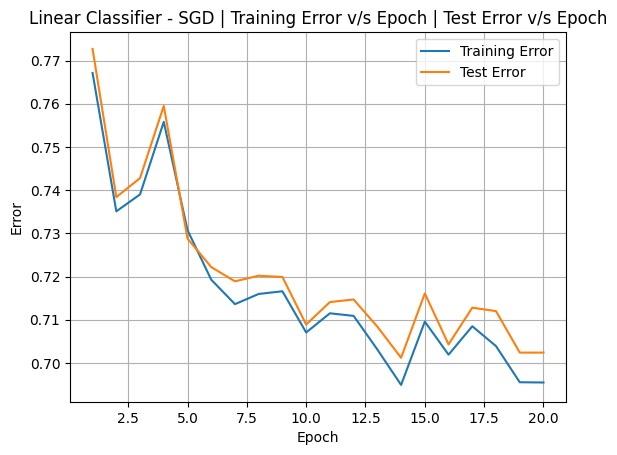

In [26]:
# Optimizer 1 - SGD 
W_sgd, b_sgd, train_errors, test_errors = fit_sgd(train_x, train_y, test_x, test_y, lr=0.005)
plot_errors(train_errors, test_errors, "Linear Classifier - SGD | Training Error v/s Epoch | Test Error v/s Epoch")

os.makedirs("saved_models/linear_classifier", exist_ok=True)
np.save("saved_models/linear_classifier/sgd_train.npy", np.array(train_errors))
np.save("saved_models/linear_classifier/sgd_test.npy",  np.array(test_errors))
np.savez("saved_models/linear_classifier/sgd_model.npz", W=W_sgd, b=b_sgd)

In [27]:
# Linear Classifier - SGD with momentum Table 2
def train_sgdm_step(W, b, mean_g_W, mean_g_b, x, y, lr, beta):
    def loss_fn(W_, B_):
        return cross_entropy_loss(W_, B_, x, y)
    loss, (dW, db) = jax.value_and_grad(loss_fn, argnums=(0, 1))(W, b)

    mean_g_W_new = (1.0 - beta) * mean_g_W + beta * dW
    mean_g_b_new = (1.0 - beta) * mean_g_b + beta * db

    W_new = W - lr * mean_g_W_new
    B_new = b - lr * mean_g_b_new
    return W_new, B_new, mean_g_W_new, mean_g_b_new, loss


def fit_sgdm(train_x, train_y, test_x, test_y, lr, beta=0.9, epochs=20, batch_size=64, seed=0):
    key = jax.random.PRNGKey(seed)
    W, b = init_linear_params(key)
    mean_g_W = jnp.zeros_like(W)
    mean_g_b = jnp.zeros_like(b)
    train_errors=[]
    test_errors=[]
    for epoch in range(epochs):
        rng = np.random.default_rng(seed + epoch)
        for xn, yn in mini_batch(train_x, train_y, batch_size, rng):
            xn = jnp.array(xn)
            yn = jnp.array(yn)
            W, b, mean_g_W, mean_g_b, loss = train_sgdm_step(W, b, mean_g_W, mean_g_b, xn, yn, lr, beta)
        
        train_accuracy = float(accuracy(W, b, jnp.array(train_x), jnp.array(train_y)))
        train_errors.append(1-train_accuracy)
        test_accuracy = float(accuracy(W, b, jnp.array(test_x), jnp.array(test_y)))
        test_errors.append(1-test_accuracy)
        print(f"[Linear Classifier - SGDM] epoch={epoch+1:02d} | loss={float(loss):.4f} | test_accuracy={test_accuracy:.4f}")
    return W, b, train_errors, test_errors

[Linear Classifier - SGDM] epoch=01 | loss=2.3507 | test_accuracy=0.2279
[Linear Classifier - SGDM] epoch=02 | loss=2.0067 | test_accuracy=0.2615
[Linear Classifier - SGDM] epoch=03 | loss=1.8691 | test_accuracy=0.2593
[Linear Classifier - SGDM] epoch=04 | loss=2.4012 | test_accuracy=0.2438
[Linear Classifier - SGDM] epoch=05 | loss=2.1600 | test_accuracy=0.2724
[Linear Classifier - SGDM] epoch=06 | loss=2.0864 | test_accuracy=0.2756
[Linear Classifier - SGDM] epoch=07 | loss=2.3225 | test_accuracy=0.2812
[Linear Classifier - SGDM] epoch=08 | loss=1.8924 | test_accuracy=0.2800
[Linear Classifier - SGDM] epoch=09 | loss=1.8751 | test_accuracy=0.2808
[Linear Classifier - SGDM] epoch=10 | loss=2.1072 | test_accuracy=0.2905
[Linear Classifier - SGDM] epoch=11 | loss=1.9974 | test_accuracy=0.2877
[Linear Classifier - SGDM] epoch=12 | loss=1.9860 | test_accuracy=0.2867
[Linear Classifier - SGDM] epoch=13 | loss=2.0573 | test_accuracy=0.2933
[Linear Classifier - SGDM] epoch=14 | loss=1.9358 |

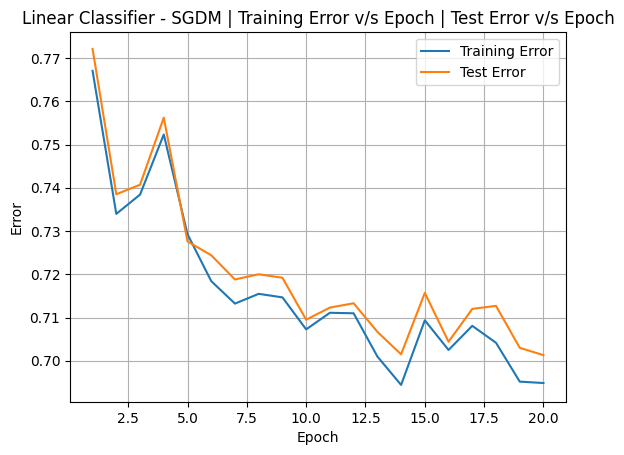

In [28]:
# Table 2 Linear Classifier - SGD with momentum
W_sgd, b_sgd, train_errors, test_errors = fit_sgdm(train_x, train_y, test_x, test_y, lr=0.005)
plot_errors(train_errors, test_errors, "Linear Classifier - SGDM | Training Error v/s Epoch | Test Error v/s Epoch")

np.save("saved_models/linear_classifier/sgdm_train.npy", np.array(train_errors))
np.save("saved_models/linear_classifier/sgdm_test.npy",  np.array(test_errors))
np.savez("saved_models/linear_classifier/sgdm_model.npz", W=W_sgd, b=b_sgd)

In [30]:
# Linear Classifier - Adam Table 2
def train_adam_step(W, b, mean_g_W, mean_g_b, mean_g2_W, mean_g2_b, x, y, lr, beta1, beta2, eps=1e-7):
    def loss_fn(W_, B_):
        return cross_entropy_loss(W_, B_, x, y)
        
    loss, (dW, db) = jax.value_and_grad(loss_fn, argnums=(0, 1))(W, b)
    
    mean_g_W_new = beta1*mean_g_W + (1.0-beta1)*dW
    mean_g_b_new = beta1*mean_g_b + (1.0-beta1)*db

    mean_g2_W_new = beta2*mean_g2_W + (1.0-beta2)*(dW * dW)
    mean_g2_b_new = beta2*mean_g2_b + (1.0-beta2)*(db * db)

    W_new = W - lr*mean_g_W_new/(jnp.sqrt(mean_g2_W_new) + eps)
    b_new = b - lr*mean_g_b_new/(jnp.sqrt(mean_g2_b_new) + eps)
    
    return (W_new, b_new, mean_g_W_new, mean_g_b_new, mean_g2_W_new, mean_g2_b_new, loss)

def fit_adam(train_x, train_y, test_x, test_y, lr, beta1=0.9, beta2=0.999, epochs=20, batch_size=64, seed=0):
    key = jax.random.PRNGKey(seed)
    W, b = init_linear_params(key)

    train_errors=[]
    test_errors=[]
    mean_g_W  = jnp.zeros_like(W)
    mean_g_b  = jnp.zeros_like(b)
    mean_g2_W = jnp.zeros_like(W)
    mean_g2_b = jnp.zeros_like(b)

    for epoch in range(epochs):
        rng = np.random.default_rng(seed + epoch)
        for xn, yn in mini_batch(train_x, train_y, batch_size, rng):
            xn = jnp.array(xn)
            yn = jnp.array(yn)
            (W, b, mean_g_W, mean_g_b, mean_g2_W, mean_g2_b, loss) = train_adam_step(W, b,mean_g_W, mean_g_b, 
                                                                                     mean_g2_W, mean_g2_b, xn, yn, 
                                                                                     lr=lr, beta1=beta1, beta2=beta2)

        train_accuracy = float(accuracy(W, b, jnp.array(train_x), jnp.array(train_y)))
        train_errors.append(1-train_accuracy)
        test_accuracy = float(accuracy(W, b, jnp.array(test_x), jnp.array(test_y)))
        test_errors.append(1-test_accuracy)
        print(f"[Linear Classifier - Adam] epoch={epoch+1:02d} | loss={float(loss):.4f} | test_accuracy={test_accuracy:.4f}")

    return W, b, train_errors, test_errors


[Linear Classifier - Adam] epoch=01 | loss=2.3220 | test_accuracy=0.2488
[Linear Classifier - Adam] epoch=02 | loss=2.0090 | test_accuracy=0.2692
[Linear Classifier - Adam] epoch=03 | loss=1.8528 | test_accuracy=0.2681
[Linear Classifier - Adam] epoch=04 | loss=2.4038 | test_accuracy=0.2732
[Linear Classifier - Adam] epoch=05 | loss=2.1372 | test_accuracy=0.2718
[Linear Classifier - Adam] epoch=06 | loss=2.0472 | test_accuracy=0.2777
[Linear Classifier - Adam] epoch=07 | loss=2.2938 | test_accuracy=0.2764
[Linear Classifier - Adam] epoch=08 | loss=1.8789 | test_accuracy=0.2846
[Linear Classifier - Adam] epoch=09 | loss=1.8409 | test_accuracy=0.2816
[Linear Classifier - Adam] epoch=10 | loss=2.0993 | test_accuracy=0.2922
[Linear Classifier - Adam] epoch=11 | loss=1.9382 | test_accuracy=0.2915
[Linear Classifier - Adam] epoch=12 | loss=2.0115 | test_accuracy=0.2895
[Linear Classifier - Adam] epoch=13 | loss=2.0592 | test_accuracy=0.2892
[Linear Classifier - Adam] epoch=14 | loss=1.9329 |

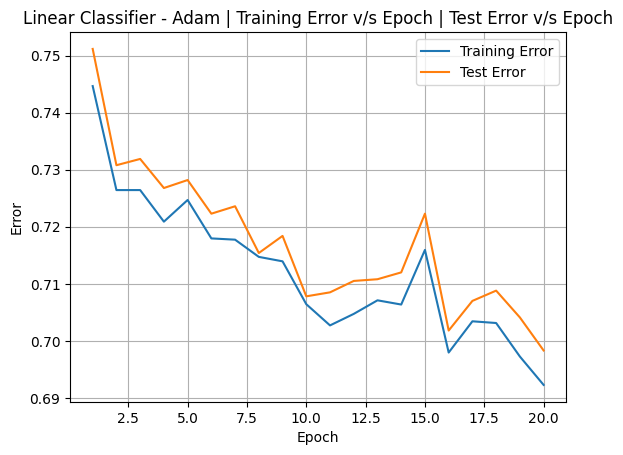

In [32]:
# Optimizer 3 - Adam
W_sgd, b_sgd, train_errors, test_errors = fit_adam(train_x, train_y, test_x, test_y, lr=0.0001)
plot_errors(train_errors, test_errors, "Linear Classifier - Adam | Training Error v/s Epoch | Test Error v/s Epoch")

np.save("saved_models/linear_classifier/adam_train.npy", np.array(train_errors))
np.save("saved_models/linear_classifier/adam_test.npy",  np.array(test_errors))
np.savez("saved_models/linear_classifier/adam_model.npz", W=W_sgd, b=b_sgd)

[Shallow MLP - SGD] epoch=01 | loss=2.3295 | test_accuracy=0.2541
[Shallow MLP - SGD] epoch=02 | loss=2.0175 | test_accuracy=0.2892
[Shallow MLP - SGD] epoch=03 | loss=1.8573 | test_accuracy=0.2861
[Shallow MLP - SGD] epoch=04 | loss=2.2866 | test_accuracy=0.2433
[Shallow MLP - SGD] epoch=05 | loss=2.1152 | test_accuracy=0.2811
[Shallow MLP - SGD] epoch=06 | loss=2.0674 | test_accuracy=0.3053
[Shallow MLP - SGD] epoch=07 | loss=2.2610 | test_accuracy=0.3120
[Shallow MLP - SGD] epoch=08 | loss=1.7878 | test_accuracy=0.3118
[Shallow MLP - SGD] epoch=09 | loss=1.8283 | test_accuracy=0.3152
[Shallow MLP - SGD] epoch=10 | loss=1.9480 | test_accuracy=0.3304
[Shallow MLP - SGD] epoch=11 | loss=1.7727 | test_accuracy=0.3352
[Shallow MLP - SGD] epoch=12 | loss=2.0214 | test_accuracy=0.3365
[Shallow MLP - SGD] epoch=13 | loss=2.0490 | test_accuracy=0.3307
[Shallow MLP - SGD] epoch=14 | loss=1.8302 | test_accuracy=0.3369
[Shallow MLP - SGD] epoch=15 | loss=1.7485 | test_accuracy=0.3318
[Shallow M

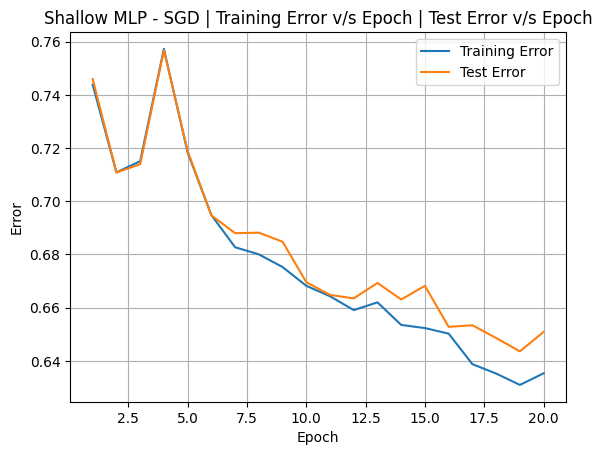

In [34]:
# Architecture 2 - Shallow MLP Scenario
def init_shallow_mlp_params(key, in_dimension=1024, hidden_dimension=128, out_dimension=10):
    k1, k2 = jax.random.split(key)
    W1 = jax.random.normal(k1, (in_dimension, hidden_dimension))*(1.0/jnp.sqrt(in_dimension))
    b1 = jnp.zeros((hidden_dimension,))
    W2 = jax.random.normal(k2, (hidden_dimension, out_dimension))*(1.0/jnp.sqrt(hidden_dimension))
    b2 = jnp.zeros((out_dimension,))
    return {"W1": W1, "b1": b1, "W2": W2, "b2": b2}

def shallow_mlp_forward_pass(params, x):
    h = jnp.tanh(jnp.dot(x, params["W1"]) + params["b1"])
    logits = jnp.dot(h, params["W2"]) + params["b2"]
    return logits

def shallow_mlp_loss_func(params, x, y):
    logits = shallow_mlp_forward_pass(params, x)
    log_prob = jax.nn.log_softmax(logits, axis=-1)
    neg_log_likelihood = -log_prob[jnp.arange(x.shape[0]),y]
    return neg_log_likelihood.mean()

def shallow_mlp_accuracy(params, x, y):
    logits = shallow_mlp_forward_pass(params, x)
    preds = jnp.argmax(logits, axis=-1)
    return (preds==y).mean()

def train_shallow_mlp_sgd_step(params, x, y, lr):
    def loss_fn(p):
        return shallow_mlp_loss_func(p, x, y)
    loss, grads = jax.value_and_grad(loss_fn)(params)

    updated_params = {"W1": params["W1"]-lr*grads["W1"], "b1": params["b1"]-lr*grads["b1"],
                  "W2": params["W2"]-lr*grads["W2"], "b2": params["b2"]-lr*grads["b2"],}
    return updated_params, loss

def fit_sgd_shallow_mlp(train_x, train_y, test_x, test_y, lr, epochs=20, batch_size=64, seed=0):
    key = jax.random.PRNGKey(seed)
    params = init_shallow_mlp_params(key)

    train_errors = []
    test_errors = []
    
    for epoch in range(epochs):
        rng = np.random.default_rng(seed + epoch)
        for xn, yn in mini_batch(train_x, train_y, batch_size, rng):
            xn = jnp.array(xn)
            yn = jnp.array(yn)
            params, loss = train_shallow_mlp_sgd_step(params, xn, yn, lr)

        train_accuracy = float(shallow_mlp_accuracy(params, jnp.array(train_x), jnp.array(train_y)))
        train_errors.append(1-train_accuracy)
        test_accuracy = float(shallow_mlp_accuracy(params, jnp.array(test_x), jnp.array(test_y)))
        test_errors.append(1-test_accuracy)
        print(f"[Shallow MLP - SGD] epoch={epoch+1:02d} | loss={float(loss):.4f} | test_accuracy={test_accuracy:.4f}")
    return params, train_errors, test_errors

# Shallow MLP - SGD
params, train_errors, test_errors = fit_sgd_shallow_mlp(train_x, train_y, test_x, test_y, lr=0.01)
plot_errors(train_errors, test_errors, "Shallow MLP - SGD | Training Error v/s Epoch | Test Error v/s Epoch")

In [152]:
os.makedirs("saved_models/shallow_mlp", exist_ok=True)
np.save("saved_models/shallow_mlp/sgd_train.npy", np.array(train_errors))
np.save("saved_models/shallow_mlp/sgd_test.npy",  np.array(test_errors))
np.savez("saved_models/shallow_mlp/sgd_model.npz", W1=np.array(params["W1"]), 
         b1=np.array(params["b1"]), W2=np.array(params["W2"]), 
         b2=np.array(params["b2"]),)

[Shallow MLP - SGDM] epoch=01 | loss=2.3291 | test_accuracy=0.2554
[Shallow MLP - SGDM] epoch=02 | loss=2.0150 | test_accuracy=0.2911
[Shallow MLP - SGDM] epoch=03 | loss=1.8537 | test_accuracy=0.2881
[Shallow MLP - SGDM] epoch=04 | loss=2.2939 | test_accuracy=0.2481
[Shallow MLP - SGDM] epoch=05 | loss=2.1157 | test_accuracy=0.2843
[Shallow MLP - SGDM] epoch=06 | loss=2.0644 | test_accuracy=0.3054
[Shallow MLP - SGDM] epoch=07 | loss=2.2594 | test_accuracy=0.3140
[Shallow MLP - SGDM] epoch=08 | loss=1.7864 | test_accuracy=0.3141
[Shallow MLP - SGDM] epoch=09 | loss=1.8246 | test_accuracy=0.3176
[Shallow MLP - SGDM] epoch=10 | loss=1.9484 | test_accuracy=0.3325
[Shallow MLP - SGDM] epoch=11 | loss=1.7705 | test_accuracy=0.3352
[Shallow MLP - SGDM] epoch=12 | loss=2.0222 | test_accuracy=0.3376
[Shallow MLP - SGDM] epoch=13 | loss=2.0501 | test_accuracy=0.3314
[Shallow MLP - SGDM] epoch=14 | loss=1.8290 | test_accuracy=0.3363
[Shallow MLP - SGDM] epoch=15 | loss=1.7475 | test_accuracy=0.

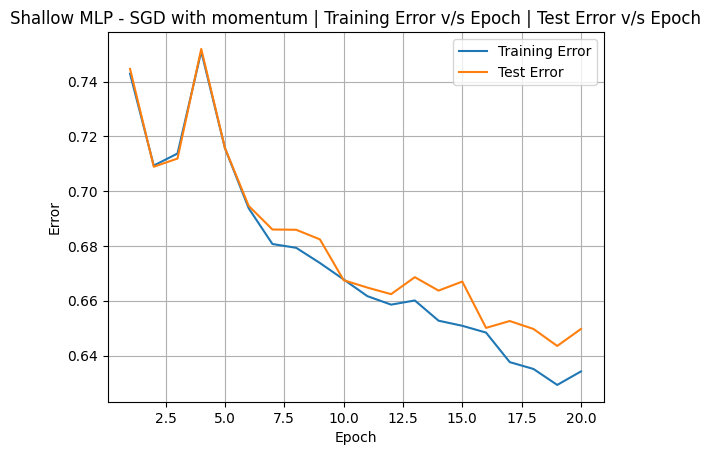

In [186]:
# Shallow MLP  Table 3 - SGD with momentum
def shallow_mlp_sgdm_step(params, mean_g, x, y, lr, beta):
    def loss_fn(p):
        return shallow_mlp_loss_func(p, x, y)
    loss, grads = jax.value_and_grad(loss_fn)(params)
    new_mean_g = {}
    new_params = {}
    for name in params.keys():
        mg = (1.0-beta)*mean_g[name]+grads[name]*beta
        w_new = params[name] - lr * mg
        new_mean_g[name] = mg
        new_params[name] = w_new
    return new_params, new_mean_g, loss

def fit_shallow_mlp_sgdm(train_x, train_y, test_x, test_y, lr, beta=0.9, epochs=20, batch_size=64, seed=0):
    key = jax.random.PRNGKey(seed)
    params = init_shallow_mlp_params(key)
    mean_g = {k: jnp.zeros_like(v) for k, v in params.items()}
    train_errors=[]
    test_errors=[]
    for epoch in range(epochs):
        rng = np.random.default_rng(seed + epoch)
        for xn, yn in mini_batch(train_x, train_y, batch_size, rng):
            xn = jnp.array(xn)
            yn = jnp.array(yn)
            params, mean_g, loss = shallow_mlp_sgdm_step(params, mean_g, xn, yn, lr, beta)
        
        train_accuracy = float(shallow_mlp_accuracy(params, jnp.array(train_x), jnp.array(train_y)))
        train_errors.append(1-train_accuracy)
        test_accuracy = float(shallow_mlp_accuracy(params, jnp.array(test_x), jnp.array(test_y)))
        test_errors.append(1-test_accuracy)
        print(f"[Shallow MLP - SGDM] epoch={epoch+1:02d} | loss={float(loss):.4f} | test_accuracy={test_accuracy:.4f}")
    return params, train_errors, test_errors

# Shallow MLP - SGD with momentum
params, train_errors, test_errors = fit_shallow_mlp_sgdm(train_x, train_y, test_x, test_y, lr=0.01)
plot_errors(train_errors, test_errors, "Shallow MLP - SGD with momentum | Training Error v/s Epoch | Test Error v/s Epoch")

In [160]:
np.save("saved_models/shallow_mlp/sgdm_train.npy", np.array(train_errors))
np.save("saved_models/shallow_mlp/sgdm_test.npy",  np.array(test_errors))
np.savez("saved_models/shallow_mlp/sgdm_model.npz", W1=np.array(params["W1"]), 
         b1=np.array(params["b1"]), W2=np.array(params["W2"]), 
         b2=np.array(params["b2"]),)

[Shallow MLP - Adam] epoch=01 | loss=2.1481 | test_accuracy=0.2826
[Shallow MLP - Adam] epoch=02 | loss=1.9434 | test_accuracy=0.3373
[Shallow MLP - Adam] epoch=03 | loss=1.5814 | test_accuracy=0.3447
[Shallow MLP - Adam] epoch=04 | loss=2.0638 | test_accuracy=0.3577
[Shallow MLP - Adam] epoch=05 | loss=1.9612 | test_accuracy=0.3662
[Shallow MLP - Adam] epoch=06 | loss=1.8292 | test_accuracy=0.3709
[Shallow MLP - Adam] epoch=07 | loss=1.9996 | test_accuracy=0.3695
[Shallow MLP - Adam] epoch=08 | loss=1.4452 | test_accuracy=0.3789
[Shallow MLP - Adam] epoch=09 | loss=1.6951 | test_accuracy=0.3811
[Shallow MLP - Adam] epoch=10 | loss=1.6494 | test_accuracy=0.3952
[Shallow MLP - Adam] epoch=11 | loss=1.3797 | test_accuracy=0.3977
[Shallow MLP - Adam] epoch=12 | loss=1.9569 | test_accuracy=0.3942
[Shallow MLP - Adam] epoch=13 | loss=1.8331 | test_accuracy=0.3900
[Shallow MLP - Adam] epoch=14 | loss=1.6771 | test_accuracy=0.3950
[Shallow MLP - Adam] epoch=15 | loss=1.6290 | test_accuracy=0.

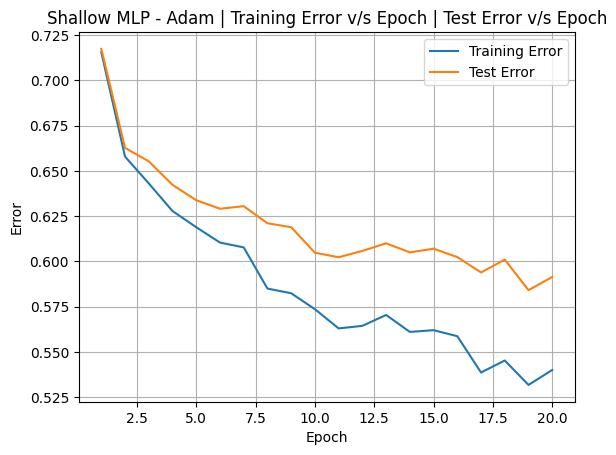

In [36]:
# Shallow MLP - Adam
def shallow_mlp_adam_step(params, mean_g, mean_g2, x, y, lr, beta1, beta2, eps=1e-7):
    def loss_fn(p):
        return shallow_mlp_loss_func(p, x, y)
    loss, grads = jax.value_and_grad(loss_fn)(params)

    new_params = {}
    new_mean_g = {}
    new_mean_g2 = {}

    for name in params.keys():
        g = grads[name]
        mg = beta1*mean_g[name]+(1.0-beta1)*g
        mg2 = beta2*mean_g2[name]+(1.0-beta2)*(g*g)
        w_new = params[name]-lr* mg/(jnp.sqrt(mg2)+eps)

        new_params[name] = w_new
        new_mean_g[name] = mg
        new_mean_g2[name] = mg2

    return new_params, new_mean_g, new_mean_g2, loss

def fit_adam_shallow_mlp(train_x, train_y, test_x, test_y, lr, beta1=0.9, beta2=0.9, epochs=20, batch_size=64, seed=0):
    key = jax.random.PRNGKey(seed)
    params = init_shallow_mlp_params(key)
    mean_g = {k: jnp.zeros_like(v) for k, v in params.items()}
    mean_g2 = {k: jnp.zeros_like(v) for k, v in params.items()}

    train_errors=[]
    test_errors=[]

    for epoch in range(epochs):
        rng = np.random.default_rng(seed + epoch)
        for xn, yn in mini_batch(train_x, train_y, batch_size, rng):
            xn = jnp.array(xn)
            yn = jnp.array(yn)
            (params, mean_g, mean_g2, loss) = shallow_mlp_adam_step(params, mean_g, mean_g2, xn, yn, lr=lr, beta1=beta1, beta2=beta2)

        train_accuracy = float(shallow_mlp_accuracy(params, jnp.array(train_x), jnp.array(train_y)))
        train_errors.append(1-train_accuracy)
        test_accuracy = float(shallow_mlp_accuracy(params, jnp.array(test_x), jnp.array(test_y)))
        test_errors.append(1-test_accuracy)
        print(f"[Shallow MLP - Adam] epoch={epoch+1:02d} | loss={float(loss):.4f} | test_accuracy={test_accuracy:.4f}")

    return params, train_errors, test_errors

# Shallow MLP - Adam
params, train_errors, test_errors = fit_adam_shallow_mlp(train_x, train_y, test_x, test_y, lr=0.0005)
plot_errors(train_errors, test_errors, "Shallow MLP - Adam | Training Error v/s Epoch | Test Error v/s Epoch")

In [171]:
np.save("saved_models/shallow_mlp/adam_train.npy", np.array(train_errors))
np.save("saved_models/shallow_mlp/adam_test.npy",  np.array(test_errors))
np.savez("saved_models/shallow_mlp/adam_model.npz", W1=np.array(params["W1"]), 
         b1=np.array(params["b1"]), W2=np.array(params["W2"]), 
         b2=np.array(params["b2"]),)

[Deep MLP - SGD] epoch=01 | loss=2.2835 | test_accuracy=0.2565
[Deep MLP - SGD] epoch=02 | loss=2.0041 | test_accuracy=0.2862
[Deep MLP - SGD] epoch=03 | loss=1.7990 | test_accuracy=0.2839
[Deep MLP - SGD] epoch=04 | loss=2.3175 | test_accuracy=0.2448
[Deep MLP - SGD] epoch=05 | loss=2.0727 | test_accuracy=0.2792
[Deep MLP - SGD] epoch=06 | loss=1.9859 | test_accuracy=0.3217
[Deep MLP - SGD] epoch=07 | loss=2.1327 | test_accuracy=0.3116
[Deep MLP - SGD] epoch=08 | loss=1.8026 | test_accuracy=0.3240
[Deep MLP - SGD] epoch=09 | loss=1.9084 | test_accuracy=0.3216
[Deep MLP - SGD] epoch=10 | loss=1.7783 | test_accuracy=0.3489
[Deep MLP - SGD] epoch=11 | loss=1.6532 | test_accuracy=0.3384
[Deep MLP - SGD] epoch=12 | loss=1.9269 | test_accuracy=0.3429
[Deep MLP - SGD] epoch=13 | loss=2.0157 | test_accuracy=0.3416
[Deep MLP - SGD] epoch=14 | loss=1.8866 | test_accuracy=0.3580
[Deep MLP - SGD] epoch=15 | loss=1.7456 | test_accuracy=0.3574
[Deep MLP - SGD] epoch=16 | loss=1.7299 | test_accuracy

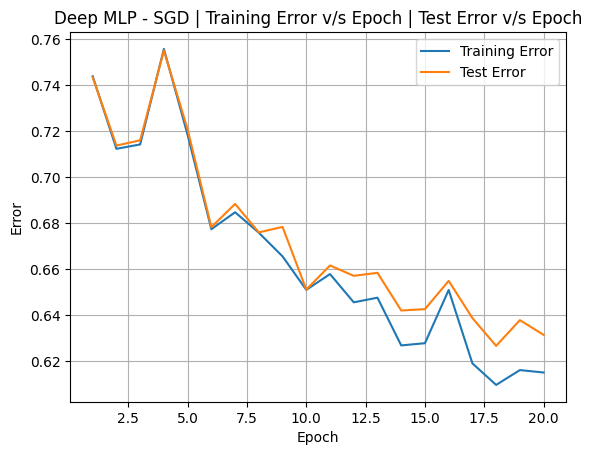

In [38]:
# Table 4 - Deep MLP Scenario
def init_deep_mlp_params(key, in_dimension=1024, hidden_dimension=128, out_dimension=10):
    k1, k2 = jax.random.split(key)
    k3, k4 = jax.random.split(k2)
    k5, k5  = jax.random.split(k4)
    params = {
        "W1": jax.random.normal(k1, (in_dimension, hidden_dimension))*(1.0 / jnp.sqrt(in_dimension)),
        "b1": jnp.zeros((hidden_dimension,)),
        
        "W2": jax.random.normal(k3, (hidden_dimension, hidden_dimension))*(1.0 / jnp.sqrt(hidden_dimension)),
        "b2": jnp.zeros((hidden_dimension,)),
        
        "W3": jax.random.normal(k4, (hidden_dimension, hidden_dimension))*(1.0 / jnp.sqrt(hidden_dimension)),
        "b3": jnp.zeros((hidden_dimension,)),

        "W4": jax.random.normal(k5, (hidden_dimension, out_dimension))*(1.0 / jnp.sqrt(hidden_dimension)),
        "b4": jnp.zeros((out_dimension,)),
    }
    return params

def deep_mlp_forward_pass(params, x):
    h1 = jnp.tanh(jnp.dot(x, params["W1"]) + params["b1"])
    h2 = jnp.tanh(jnp.dot(h1, params["W2"]) + params["b2"])
    h3 = jnp.tanh(jnp.dot(h2, params["W3"]) + params["b3"])
    logits = jnp.dot(h3, params["W4"]) + params["b4"]
    return logits

def deep_mlp_loss_func(params, x, y):
    logits = deep_mlp_forward_pass(params, x)
    log_prob = jax.nn.log_softmax(logits,axis=-1)
    neg_log_likelihood = -log_prob[jnp.arange(x.shape[0]),y]
    return neg_log_likelihood.mean()

def deep_mlp_accuracy(params, x, y):
    logits = deep_mlp_forward_pass(params, x)
    preds = jnp.argmax(logits, axis=-1)
    return (preds==y).mean()

def train_deep_mlp_sgd_step(params, x, y, lr):
    def loss_fn(p):
        return deep_mlp_loss_func(p, x, y)
    loss, grads = jax.value_and_grad(loss_fn)(params)
    updated_params = {}
    for name in params.keys():
        updated_params[name]=params[name]-lr*grads[name]
    return updated_params, loss

def fit_sgd_deep_mlp(train_x, train_y, test_x, test_y, lr, epochs=20, batch_size=64, seed=0):
    key = jax.random.PRNGKey(seed)
    params = init_deep_mlp_params(key)

    train_errors = []
    test_errors = []
    
    for epoch in range(epochs):
        rng = np.random.default_rng(seed + epoch)
        for xn, yn in mini_batch(train_x, train_y, batch_size, rng):
            xn = jnp.array(xn)
            yn = jnp.array(yn)
            params, loss = train_deep_mlp_sgd_step(params, xn, yn, lr)

        train_accuracy = float(deep_mlp_accuracy(params, jnp.array(train_x), jnp.array(train_y)))
        train_errors.append(1-train_accuracy)
        test_accuracy = float(deep_mlp_accuracy(params, jnp.array(test_x), jnp.array(test_y)))
        test_errors.append(1-test_accuracy)
        print(f"[Deep MLP - SGD] epoch={epoch+1:02d} | loss={float(loss):.4f} | test_accuracy={test_accuracy:.4f}")
    return params, train_errors, test_errors

# Deep MLP - SGD
params, train_errors, test_errors = fit_sgd_deep_mlp(train_x, train_y, test_x, test_y, lr=0.01)
plot_errors(train_errors, test_errors, "Deep MLP - SGD | Training Error v/s Epoch | Test Error v/s Epoch")

In [42]:
os.makedirs("saved_models/deep_mlp", exist_ok=True)
np.save("saved_models/deep_mlp/sgd_train.npy", np.array(train_errors))
np.save("saved_models/deep_mlp/sgd_test.npy",  np.array(test_errors))
np.savez("saved_models/deep_mlp/sgd_model.npz", W1=np.array(params["W1"]), b1=np.array(params["b1"]), 
         W2=np.array(params["W2"]), b2=np.array(params["b2"]), 
         W3=np.array(params["W3"]), b3=np.array(params["b3"]), 
         W4=np.array(params["W4"]), b4=np.array(params["b4"]),)

[Deep MLP - SGDM] epoch=01 | loss=2.2817 | test_accuracy=0.2572
[Deep MLP - SGDM] epoch=02 | loss=2.0002 | test_accuracy=0.2878
[Deep MLP - SGDM] epoch=03 | loss=1.7943 | test_accuracy=0.2863
[Deep MLP - SGDM] epoch=04 | loss=2.3215 | test_accuracy=0.2534
[Deep MLP - SGDM] epoch=05 | loss=2.0730 | test_accuracy=0.2831
[Deep MLP - SGDM] epoch=06 | loss=1.9803 | test_accuracy=0.3243
[Deep MLP - SGDM] epoch=07 | loss=2.1328 | test_accuracy=0.3165
[Deep MLP - SGDM] epoch=08 | loss=1.7996 | test_accuracy=0.3238
[Deep MLP - SGDM] epoch=09 | loss=1.9096 | test_accuracy=0.3276
[Deep MLP - SGDM] epoch=10 | loss=1.7726 | test_accuracy=0.3518
[Deep MLP - SGDM] epoch=11 | loss=1.6520 | test_accuracy=0.3397
[Deep MLP - SGDM] epoch=12 | loss=1.9345 | test_accuracy=0.3452
[Deep MLP - SGDM] epoch=13 | loss=2.0215 | test_accuracy=0.3475
[Deep MLP - SGDM] epoch=14 | loss=1.8792 | test_accuracy=0.3591
[Deep MLP - SGDM] epoch=15 | loss=1.7488 | test_accuracy=0.3581
[Deep MLP - SGDM] epoch=16 | loss=1.7325

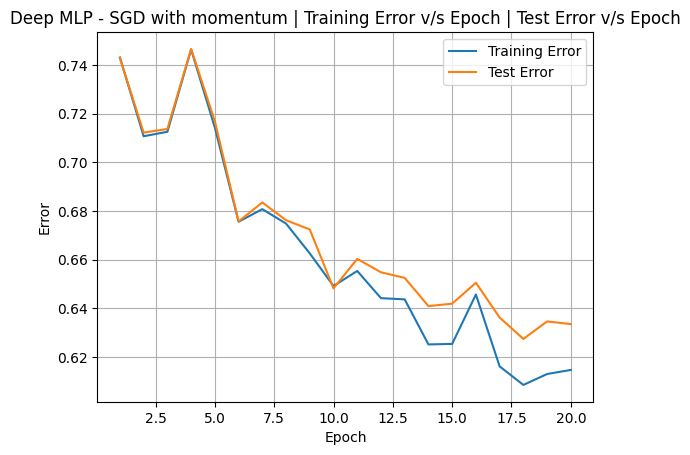

In [189]:
# Deep MLP - SGD with momentum
def deep_mlp_sgdm_step(params, mean_g, x, y, lr, beta):
    def loss_fn(p):
        return deep_mlp_loss_func(p, x, y)
    loss, grads = jax.value_and_grad(loss_fn)(params)
    new_mean_g = {}
    new_params = {}
    for name in params.keys():
        mg = (1.0-beta)*mean_g[name]+grads[name]*beta
        w_new = params[name] - lr * mg
        new_mean_g[name] = mg
        new_params[name] = w_new
    return new_params, new_mean_g, loss

def fit_deep_mlp_sgdm(train_x, train_y, test_x, test_y, lr, beta=0.9, epochs=20, batch_size=64, seed=0):
    key = jax.random.PRNGKey(seed)
    params = init_deep_mlp_params(key)
    mean_g = {k: jnp.zeros_like(v) for k, v in params.items()}
    train_errors=[]
    test_errors=[]
    for epoch in range(epochs):
        rng = np.random.default_rng(seed + epoch)
        for xn, yn in mini_batch(train_x, train_y, batch_size, rng):
            xn = jnp.array(xn)
            yn = jnp.array(yn)
            params, mean_g, loss = deep_mlp_sgdm_step(params, mean_g, xn, yn, lr, beta)
        
        train_accuracy = float(deep_mlp_accuracy(params, jnp.array(train_x), jnp.array(train_y)))
        train_errors.append(1-train_accuracy)
        test_accuracy = float(deep_mlp_accuracy(params, jnp.array(test_x), jnp.array(test_y)))
        test_errors.append(1-test_accuracy)
        print(f"[Deep MLP - SGDM] epoch={epoch+1:02d} | loss={float(loss):.4f} | test_accuracy={test_accuracy:.4f}")
    return params, train_errors, test_errors

# Deep MLP - SGD
params, train_errors, test_errors = fit_deep_mlp_sgdm(train_x, train_y, test_x, test_y, lr=0.01)
plot_errors(train_errors, test_errors, "Deep MLP - SGD with momentum | Training Error v/s Epoch | Test Error v/s Epoch")

In [190]:
np.save("saved_models/deep_mlp/sgdm_train.npy", np.array(train_errors))
np.save("saved_models/deep_mlp/sgdm_test.npy",  np.array(test_errors))
np.savez("saved_models/deep_mlp/sgdm_model.npz", W1=np.array(params["W1"]), b1=np.array(params["b1"]), 
         W2=np.array(params["W2"]), b2=np.array(params["b2"]), 
         W3=np.array(params["W3"]), b3=np.array(params["b3"]), 
         W4=np.array(params["W4"]), b4=np.array(params["b4"]),)

[Deep MLP - Adam] epoch=01 | loss=2.1178 | test_accuracy=0.3205
[Deep MLP - Adam] epoch=02 | loss=1.7892 | test_accuracy=0.3539
[Deep MLP - Adam] epoch=03 | loss=1.5969 | test_accuracy=0.3698
[Deep MLP - Adam] epoch=04 | loss=2.2580 | test_accuracy=0.3621
[Deep MLP - Adam] epoch=05 | loss=1.8563 | test_accuracy=0.3843
[Deep MLP - Adam] epoch=06 | loss=1.8368 | test_accuracy=0.3892
[Deep MLP - Adam] epoch=07 | loss=1.9087 | test_accuracy=0.3882
[Deep MLP - Adam] epoch=08 | loss=1.3015 | test_accuracy=0.4040
[Deep MLP - Adam] epoch=09 | loss=1.6764 | test_accuracy=0.3911
[Deep MLP - Adam] epoch=10 | loss=1.5343 | test_accuracy=0.4005
[Deep MLP - Adam] epoch=11 | loss=1.3182 | test_accuracy=0.4151
[Deep MLP - Adam] epoch=12 | loss=1.6186 | test_accuracy=0.4142
[Deep MLP - Adam] epoch=13 | loss=1.8983 | test_accuracy=0.4200
[Deep MLP - Adam] epoch=14 | loss=1.7455 | test_accuracy=0.3964
[Deep MLP - Adam] epoch=15 | loss=1.6720 | test_accuracy=0.4020
[Deep MLP - Adam] epoch=16 | loss=1.4468

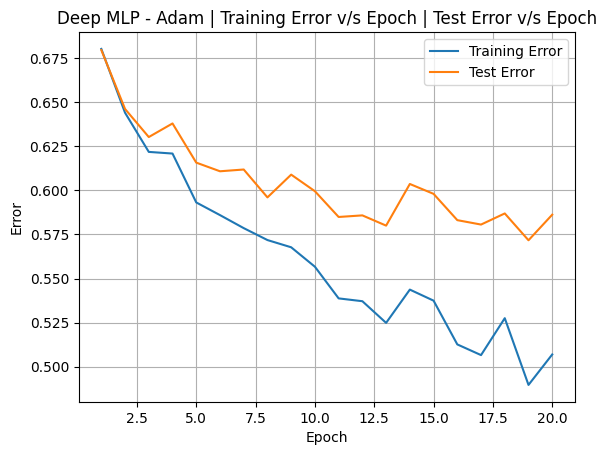

In [43]:
def deep_mlp_adam_step(params, mean_g, mean_g2, x, y, lr, beta1, beta2, eps=1e-8):
    def loss_fn(p):
        return deep_mlp_loss_func(p, x, y)
    loss, grads = jax.value_and_grad(loss_fn)(params)

    new_params = {}
    new_mean_g = {}
    new_mean_g2 = {}

    for name in params.keys():
        g = grads[name]
        mg = beta1*mean_g[name]+(1.0-beta1)*g
        mg2 = beta2*mean_g2[name]+(1.0-beta2)*(g*g)
        w_new = params[name]-lr* mg/(jnp.sqrt(mg2)+eps)

        new_params[name] = w_new
        new_mean_g[name] = mg
        new_mean_g2[name] = mg2

    return new_params, new_mean_g, new_mean_g2, loss

def fit_adam_deep_mlp(train_x, train_y, test_x, test_y, lr, beta1=0.9, beta2=0.9, epochs=20, batch_size=64, seed=0):
    key = jax.random.PRNGKey(seed)
    params = init_deep_mlp_params(key)
    mean_g = {k: jnp.zeros_like(v) for k, v in params.items()}
    mean_g2 = {k: jnp.zeros_like(v) for k, v in params.items()}

    train_errors=[]
    test_errors=[]

    for epoch in range(epochs):
        rng = np.random.default_rng(seed + epoch)
        for xn, yn in mini_batch(train_x, train_y, batch_size, rng):
            xn = jnp.array(xn)
            yn = jnp.array(yn)
            (params, mean_g, mean_g2, loss) = deep_mlp_adam_step(params, mean_g, mean_g2, xn, yn, lr=lr, beta1=beta1, beta2=beta2)

        train_accuracy = float(deep_mlp_accuracy(params, jnp.array(train_x), jnp.array(train_y)))
        train_errors.append(1-train_accuracy)
        test_accuracy = float(deep_mlp_accuracy(params, jnp.array(test_x), jnp.array(test_y)))
        test_errors.append(1-test_accuracy)
        print(f"[Deep MLP - Adam] epoch={epoch+1:02d} | loss={float(loss):.4f} | test_accuracy={test_accuracy:.4f}")

    return params, train_errors, test_errors

# Deep MLP - Adam
params, train_errors, test_errors = fit_adam_deep_mlp(train_x, train_y, test_x, test_y, lr=0.0008)
plot_errors(train_errors, test_errors, "Deep MLP - Adam | Training Error v/s Epoch | Test Error v/s Epoch")

In [44]:
np.save("saved_models/deep_mlp/adam_train.npy", np.array(train_errors))
np.save("saved_models/deep_mlp/adam_test.npy",  np.array(test_errors))
np.savez("saved_models/deep_mlp/adam_model.npz", W1=np.array(params["W1"]), b1=np.array(params["b1"]), 
         W2=np.array(params["W2"]), b2=np.array(params["b2"]), 
         W3=np.array(params["W3"]), b3=np.array(params["b3"]), 
         W4=np.array(params["W4"]), b4=np.array(params["b4"]),)

[Deep MLP ReLU - SGD] epoch=01 | loss=2.3371 | test_accuracy=0.2322
[Deep MLP ReLU - SGD] epoch=02 | loss=1.9230 | test_accuracy=0.2704
[Deep MLP ReLU - SGD] epoch=03 | loss=1.8434 | test_accuracy=0.2901
[Deep MLP ReLU - SGD] epoch=04 | loss=2.1768 | test_accuracy=0.2482
[Deep MLP ReLU - SGD] epoch=05 | loss=1.9709 | test_accuracy=0.2944
[Deep MLP ReLU - SGD] epoch=06 | loss=1.9842 | test_accuracy=0.3362
[Deep MLP ReLU - SGD] epoch=07 | loss=2.1252 | test_accuracy=0.3291
[Deep MLP ReLU - SGD] epoch=08 | loss=1.6762 | test_accuracy=0.3374
[Deep MLP ReLU - SGD] epoch=09 | loss=1.7979 | test_accuracy=0.3476
[Deep MLP ReLU - SGD] epoch=10 | loss=1.6622 | test_accuracy=0.3621
[Deep MLP ReLU - SGD] epoch=11 | loss=1.6926 | test_accuracy=0.3336
[Deep MLP ReLU - SGD] epoch=12 | loss=1.8264 | test_accuracy=0.3511
[Deep MLP ReLU - SGD] epoch=13 | loss=1.9451 | test_accuracy=0.3424
[Deep MLP ReLU - SGD] epoch=14 | loss=1.9115 | test_accuracy=0.3702
[Deep MLP ReLU - SGD] epoch=15 | loss=1.7773 | t

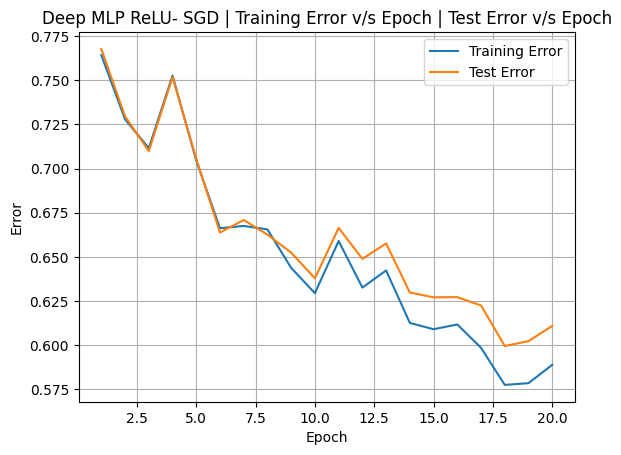

In [45]:
# Table 5 - Deep MLP with ReLU Scenario
def init_deep_mlp_relu_params(key, in_dimension=1024, hidden_dimension=128, out_dimension=10):
    k1, k2 = jax.random.split(key)
    k3, k4 = jax.random.split(k2)
    k5, k5  = jax.random.split(k4)
    params = {
        "W1": jax.random.normal(k1, (in_dimension, hidden_dimension))*(1.0 / jnp.sqrt(in_dimension)),
        "b1": jnp.zeros((hidden_dimension,)),
        
        "W2": jax.random.normal(k3, (hidden_dimension, hidden_dimension))*(1.0 / jnp.sqrt(hidden_dimension)),
        "b2": jnp.zeros((hidden_dimension,)),
        
        "W3": jax.random.normal(k4, (hidden_dimension, hidden_dimension))*(1.0 / jnp.sqrt(hidden_dimension)),
        "b3": jnp.zeros((hidden_dimension,)),

        "W4": jax.random.normal(k5, (hidden_dimension, out_dimension))*(1.0 / jnp.sqrt(hidden_dimension)),
        "b4": jnp.zeros((out_dimension,)),
    }
    return params
    
def deep_mlp_relu_forward_pass(params, x):
    h1 = jnp.maximum(jnp.dot(x, params["W1"]) + params["b1"], 0.0)
    h2 = jnp.maximum(jnp.dot(h1, params["W2"]) + params["b2"], 0.0)
    h3 = jnp.maximum(jnp.dot(h2, params["W3"]) + params["b3"], 0.0)
    logits = jnp.dot(h3, params["W4"]) + params["b4"]
    return logits

def deep_mlp_relu_loss_func(params, x, y):
    logits = deep_mlp_relu_forward_pass(params, x)
    log_prob = jax.nn.log_softmax(logits,axis=-1)
    neg_log_likelihood = -log_prob[jnp.arange(x.shape[0]),y]
    return neg_log_likelihood.mean()

def deep_mlp_relu_accuracy(params, x, y):
    logits = deep_mlp_relu_forward_pass(params, x)
    preds = jnp.argmax(logits, axis=-1)
    return (preds==y).mean()

def train_deep_mlp_relu_sgd_step(params, x, y, lr):
    def loss_fn(p):
        return deep_mlp_relu_loss_func(p, x, y)
    loss, grads = jax.value_and_grad(loss_fn)(params)
    updated_params = {}
    for name in params.keys():
        updated_params[name]=params[name]-lr*grads[name]
    return updated_params, loss

def fit_sgd_deep_mlp_relu(train_x, train_y, test_x, test_y, lr, epochs=20, batch_size=64, seed=0):
    key = jax.random.PRNGKey(seed)
    params = init_deep_mlp_relu_params(key)

    train_errors = []
    test_errors = []
    
    for epoch in range(epochs):
        rng = np.random.default_rng(seed + epoch)
        for xn, yn in mini_batch(train_x, train_y, batch_size, rng):
            xn = jnp.array(xn)
            yn = jnp.array(yn)
            params, loss = train_deep_mlp_relu_sgd_step(params, xn, yn, lr)

        train_accuracy = float(deep_mlp_relu_accuracy(params, jnp.array(train_x), jnp.array(train_y)))
        train_errors.append(1-train_accuracy)
        test_accuracy = float(deep_mlp_relu_accuracy(params, jnp.array(test_x), jnp.array(test_y)))
        test_errors.append(1-test_accuracy)
        print(f"[Deep MLP ReLU - SGD] epoch={epoch+1:02d} | loss={float(loss):.4f} | test_accuracy={test_accuracy:.4f}")
    return params, train_errors, test_errors

# Deep MLP ReLU - SGD
params, train_errors, test_errors = fit_sgd_deep_mlp_relu(train_x, train_y, test_x, test_y, lr=0.01)
plot_errors(train_errors, test_errors, "Deep MLP ReLU- SGD | Training Error v/s Epoch | Test Error v/s Epoch")

In [46]:
os.makedirs("saved_models/deep_mlp_relu", exist_ok=True)
np.save("saved_models/deep_mlp_relu/sgd_train.npy", np.array(train_errors))
np.save("saved_models/deep_mlp_relu/sgd_test.npy",  np.array(test_errors))
np.savez("saved_models/deep_mlp_relu/sgd_model.npz", W1=np.array(params["W1"]), b1=np.array(params["b1"]), 
         W2=np.array(params["W2"]), b2=np.array(params["b2"]), 
         W3=np.array(params["W3"]), b3=np.array(params["b3"]), 
         W4=np.array(params["W4"]), b4=np.array(params["b4"]),)

[Deep MLP ReLU - SGDM] epoch=01 | loss=2.3320 | test_accuracy=0.2337
[Deep MLP ReLU - SGDM] epoch=02 | loss=1.9203 | test_accuracy=0.2720
[Deep MLP ReLU - SGDM] epoch=03 | loss=1.8331 | test_accuracy=0.2905
[Deep MLP ReLU - SGDM] epoch=04 | loss=2.1879 | test_accuracy=0.2609
[Deep MLP ReLU - SGDM] epoch=05 | loss=1.9872 | test_accuracy=0.2966
[Deep MLP ReLU - SGDM] epoch=06 | loss=1.9942 | test_accuracy=0.3380
[Deep MLP ReLU - SGDM] epoch=07 | loss=2.1334 | test_accuracy=0.3271
[Deep MLP ReLU - SGDM] epoch=08 | loss=1.6938 | test_accuracy=0.3387
[Deep MLP ReLU - SGDM] epoch=09 | loss=1.8052 | test_accuracy=0.3501
[Deep MLP ReLU - SGDM] epoch=10 | loss=1.6748 | test_accuracy=0.3674
[Deep MLP ReLU - SGDM] epoch=11 | loss=1.6421 | test_accuracy=0.3402
[Deep MLP ReLU - SGDM] epoch=12 | loss=1.8905 | test_accuracy=0.3578
[Deep MLP ReLU - SGDM] epoch=13 | loss=1.9077 | test_accuracy=0.3452
[Deep MLP ReLU - SGDM] epoch=14 | loss=1.9076 | test_accuracy=0.3732
[Deep MLP ReLU - SGDM] epoch=15 | 

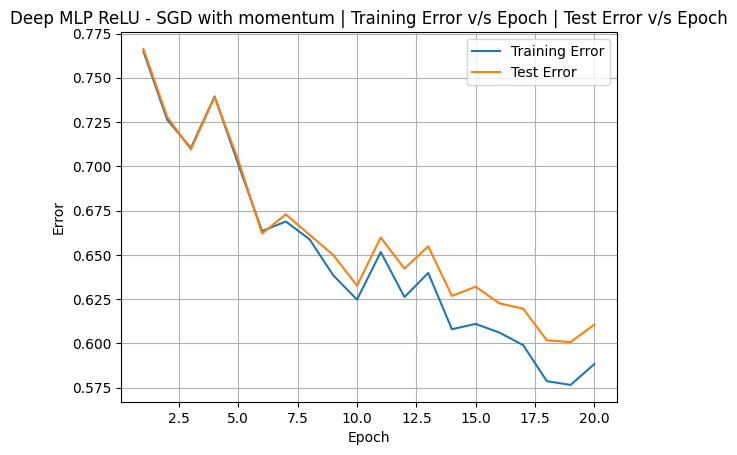

In [205]:
# Deep MLP ReLU - SGD with momentum
def deep_mlp_relu_sgdm_step(params, mean_g, x, y, lr, beta):
    def loss_fn(p):
        return deep_mlp_relu_loss_func(p, x, y)
    loss, grads = jax.value_and_grad(loss_fn)(params)
    new_mean_g = {}
    new_params = {}
    for name in params.keys():
        mg = (1.0-beta)*mean_g[name]+grads[name]*beta
        w_new = params[name] - lr * mg
        new_mean_g[name] = mg
        new_params[name] = w_new
    return new_params, new_mean_g, loss

def fit_deep_mlp_relu_sgdm(train_x, train_y, test_x, test_y, lr, beta=0.9, epochs=20, batch_size=64, seed=0):
    key = jax.random.PRNGKey(seed)
    params = init_deep_mlp_relu_params(key)
    mean_g = {k: jnp.zeros_like(v) for k, v in params.items()}
    train_errors=[]
    test_errors=[]
    for epoch in range(epochs):
        rng = np.random.default_rng(seed + epoch)
        for xn, yn in mini_batch(train_x, train_y, batch_size, rng):
            xn = jnp.array(xn)
            yn = jnp.array(yn)
            params, mean_g, loss = deep_mlp_relu_sgdm_step(params, mean_g, xn, yn, lr, beta)
        
        train_accuracy = float(deep_mlp_relu_accuracy(params, jnp.array(train_x), jnp.array(train_y)))
        train_errors.append(1-train_accuracy)
        test_accuracy = float(deep_mlp_relu_accuracy(params, jnp.array(test_x), jnp.array(test_y)))
        test_errors.append(1-test_accuracy)
        print(f"[Deep MLP ReLU - SGDM] epoch={epoch+1:02d} | loss={float(loss):.4f} | test_accuracy={test_accuracy:.4f}")
    return params, train_errors, test_errors

# Deep MLP - SGD
params, train_errors, test_errors = fit_deep_mlp_relu_sgdm(train_x, train_y, test_x, test_y, lr=0.01)
plot_errors(train_errors, test_errors, "Deep MLP ReLU - SGD with momentum | Training Error v/s Epoch | Test Error v/s Epoch")

In [207]:
np.save("saved_models/deep_mlp_relu/sgdm_train.npy", np.array(train_errors))
np.save("saved_models/deep_mlp_relu/sgdm_test.npy",  np.array(test_errors))
np.savez("saved_models/deep_mlp_relu/sgdm_model.npz", W1=np.array(params["W1"]), b1=np.array(params["b1"]), 
         W2=np.array(params["W2"]), b2=np.array(params["b2"]), 
         W3=np.array(params["W3"]), b3=np.array(params["b3"]), 
         W4=np.array(params["W4"]), b4=np.array(params["b4"]),)

[Deep MLP ReLU - Adam] epoch=01 | loss=2.0906 | test_accuracy=0.3261
[Deep MLP ReLU - Adam] epoch=02 | loss=1.7641 | test_accuracy=0.3412
[Deep MLP ReLU - Adam] epoch=03 | loss=1.8605 | test_accuracy=0.3626
[Deep MLP ReLU - Adam] epoch=04 | loss=2.0420 | test_accuracy=0.3625
[Deep MLP ReLU - Adam] epoch=05 | loss=1.9442 | test_accuracy=0.3809
[Deep MLP ReLU - Adam] epoch=06 | loss=1.7750 | test_accuracy=0.3951
[Deep MLP ReLU - Adam] epoch=07 | loss=1.8714 | test_accuracy=0.3904
[Deep MLP ReLU - Adam] epoch=08 | loss=1.3297 | test_accuracy=0.4019
[Deep MLP ReLU - Adam] epoch=09 | loss=1.6257 | test_accuracy=0.3862
[Deep MLP ReLU - Adam] epoch=10 | loss=1.4250 | test_accuracy=0.4096
[Deep MLP ReLU - Adam] epoch=11 | loss=1.1057 | test_accuracy=0.4003
[Deep MLP ReLU - Adam] epoch=12 | loss=1.4951 | test_accuracy=0.4160
[Deep MLP ReLU - Adam] epoch=13 | loss=1.8316 | test_accuracy=0.4136
[Deep MLP ReLU - Adam] epoch=14 | loss=1.5377 | test_accuracy=0.4100
[Deep MLP ReLU - Adam] epoch=15 | 

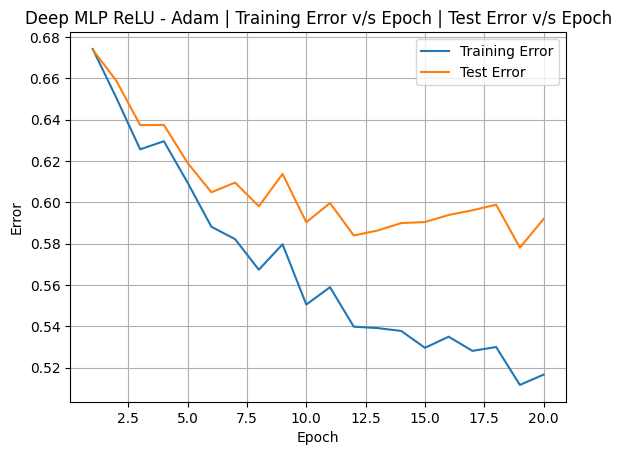

In [47]:
# Deep MLP ReLU - Adam
def deep_mlp_relu_adam_step(params, mean_g, mean_g2, x, y, lr, beta1, beta2, eps=1e-8):
    def loss_fn(p):
        return deep_mlp_relu_loss_func(p, x, y)
    loss, grads = jax.value_and_grad(loss_fn)(params)

    new_params = {}
    new_mean_g = {}
    new_mean_g2 = {}

    for name in params.keys():
        g = grads[name]
        mg = beta1*mean_g[name]+(1.0-beta1)*g
        mg2 = beta2*mean_g2[name]+(1.0-beta2)*(g*g)
        w_new = params[name]-lr* mg/(jnp.sqrt(mg2)+eps)

        new_params[name] = w_new
        new_mean_g[name] = mg
        new_mean_g2[name] = mg2

    return new_params, new_mean_g, new_mean_g2, loss

def fit_adam_deep_mlp_relu(train_x, train_y, test_x, test_y, lr, beta1=0.9, beta2=0.9, epochs=20, batch_size=64, seed=0):
    key = jax.random.PRNGKey(seed)
    params = init_deep_mlp_relu_params(key)
    mean_g = {k: jnp.zeros_like(v) for k, v in params.items()}
    mean_g2 = {k: jnp.zeros_like(v) for k, v in params.items()}

    train_errors=[]
    test_errors=[]

    for epoch in range(epochs):
        rng = np.random.default_rng(seed + epoch)
        for xn, yn in mini_batch(train_x, train_y, batch_size, rng):
            xn = jnp.array(xn)
            yn = jnp.array(yn)
            (params, mean_g, mean_g2, loss) = deep_mlp_relu_adam_step(params, mean_g, mean_g2, xn, yn, lr=lr, beta1=beta1, beta2=beta2)

        train_accuracy = float(deep_mlp_relu_accuracy(params, jnp.array(train_x), jnp.array(train_y)))
        train_errors.append(1-train_accuracy)
        test_accuracy = float(deep_mlp_relu_accuracy(params, jnp.array(test_x), jnp.array(test_y)))
        test_errors.append(1-test_accuracy)
        print(f"[Deep MLP ReLU - Adam] epoch={epoch+1:02d} | loss={float(loss):.4f} | test_accuracy={test_accuracy:.4f}")

    return params, train_errors, test_errors

params, train_errors, test_errors = fit_adam_deep_mlp_relu(train_x, train_y, test_x, test_y, lr=0.001)
plot_errors(train_errors, test_errors, "Deep MLP ReLU - Adam | Training Error v/s Epoch | Test Error v/s Epoch")

In [48]:
np.save("saved_models/deep_mlp_relu/adam_train.npy", np.array(train_errors))
np.save("saved_models/deep_mlp_relu/adam_test.npy",  np.array(test_errors))
np.savez("saved_models/deep_mlp_relu/adam_model.npz", W1=np.array(params["W1"]), b1=np.array(params["b1"]), 
         W2=np.array(params["W2"]), b2=np.array(params["b2"]), 
         W3=np.array(params["W3"]), b3=np.array(params["b3"]), 
         W4=np.array(params["W4"]), b4=np.array(params["b4"]),)

In [5]:
# CNN
def to_cnn_input(x_flat):
    # Convert back to 32x32 shape
    return x_flat.reshape(-1, 1, 32, 32)

def init_cnn_params(key, num_classes=10):
    k1, k2, k3 = jax.random.split(key, 3)

    # Layer 1: Conv2D: 32 filters, 3 × 3 kernels, 1 channel, ReLU activation
    conv1_shape = (32, 1, 3, 3)
    conv1_n_in  = 1*3*3
    conv1_n_out = 32*3*3
    conv1_std   = 1.0/jnp.sqrt(conv1_n_in+conv1_n_out)
    layer1_conv_W = conv1_std*jax.random.normal(k1, conv1_shape)
    layer1_conv_b = jnp.zeros((32,))

    # Layer 3 Conv2D: 64 filters, 3 × 3 kernels, 32 channels, ReLU activation
    conv2_shape = (64, 32, 3, 3)
    conv2_n_in  = 32*3*3
    conv2_n_out = 64*3*3
    conv2_std   = 1.0/jnp.sqrt(conv2_n_in + conv2_n_out)
    layer3_conv_W = conv2_std*jax.random.normal(k2, conv2_shape)
    layer3_conv_b = jnp.zeros((64,))

    # Layer 5 O/p after two 2x2 downsamples: 32->16->8, channels=64 -> 64*8*8
    fc_in  = 64*8*8
    fc_out = num_classes
    fc_std = 1.0/jnp.sqrt(fc_in+fc_out)
    output_fc_W = fc_std*jax.random.normal(k3, (fc_in, fc_out))
    output_fc_b = jnp.zeros((fc_out,))
    return {
        "layer1_conv_W": layer1_conv_W,
        "layer1_conv_b": layer1_conv_b,
        "layer3_conv_W": layer3_conv_W,
        "layer3_conv_b": layer3_conv_b,
        "output_fc_W": output_fc_W,
        "output_fc_b": output_fc_b,
    }

def conv_relu(x, W, b, stride=1):
    y = lax.conv_general_dilated(x, W, window_strides=(stride, stride), padding="SAME", dimension_numbers=("NCHW", "OIHW", "NCHW"))
    y = y + b.reshape(1, -1, 1, 1)
    return jnp.maximum(y, 0.0)

def maxpool_2x2(x):
    return lax.reduce_window(x,-jnp.inf,lax.max, window_dimensions=(1, 1, 2, 2), 
                             window_strides=(1, 1, 2, 2), padding="VALID")

def cnn_forward_pass(params, x):
    h1  = conv_relu(x, params["layer1_conv_W"], params["layer1_conv_b"], stride=1)
    h1p = maxpool_2x2(h1)

    h2  = conv_relu(h1p, params["layer3_conv_W"], params["layer3_conv_b"], stride=1)
    h2p = maxpool_2x2(h2)

    flat = h2p.reshape(x.shape[0], -1)
    logits = jnp.dot(flat, params["output_fc_W"]) + params["output_fc_b"]
    return logits

def cnn_loss_func(params, x, y):
    logits = cnn_forward_pass(params, x)
    log_prob = jax.nn.log_softmax(logits, axis=-1)
    neg_log_likelihood = -log_prob[jnp.arange(x.shape[0]), y]
    return neg_log_likelihood.mean()

def cnn_accuracy(params, x, y):
    logits = cnn_forward_pass(params, x)
    preds = jnp.argmax(logits, axis=-1)
    return (preds==y).mean()

[CNN - SGD] epoch=01 | loss=2.3936 | test_accuracy=0.2013
[CNN - SGD] epoch=02 | loss=2.0124 | test_accuracy=0.2590
[CNN - SGD] epoch=03 | loss=1.8618 | test_accuracy=0.2952
[CNN - SGD] epoch=04 | loss=2.2125 | test_accuracy=0.2418
[CNN - SGD] epoch=05 | loss=2.0496 | test_accuracy=0.3599
[CNN - SGD] epoch=06 | loss=1.7137 | test_accuracy=0.3228
[CNN - SGD] epoch=07 | loss=1.8184 | test_accuracy=0.4396
[CNN - SGD] epoch=08 | loss=1.4314 | test_accuracy=0.4061
[CNN - SGD] epoch=09 | loss=1.6370 | test_accuracy=0.3940
[CNN - SGD] epoch=10 | loss=1.3209 | test_accuracy=0.4547
[CNN - SGD] epoch=11 | loss=1.6402 | test_accuracy=0.3812
[CNN - SGD] epoch=12 | loss=1.3758 | test_accuracy=0.4664
[CNN - SGD] epoch=13 | loss=1.5290 | test_accuracy=0.4571
[CNN - SGD] epoch=14 | loss=1.6532 | test_accuracy=0.4997
[CNN - SGD] epoch=15 | loss=1.6533 | test_accuracy=0.4419
[CNN - SGD] epoch=16 | loss=1.4544 | test_accuracy=0.4578
[CNN - SGD] epoch=17 | loss=1.2832 | test_accuracy=0.4826
[CNN - SGD] ep

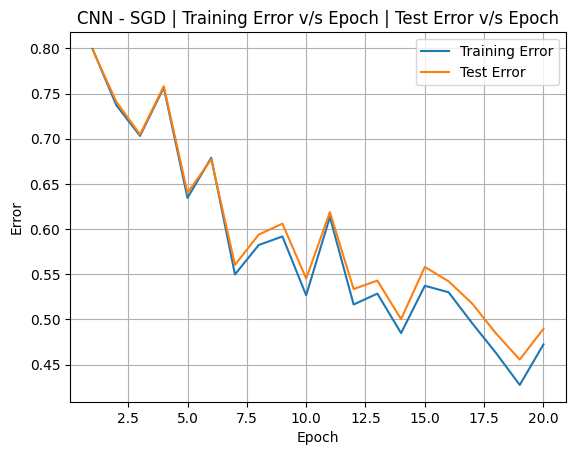

In [9]:
def train_cnn_sgd_step(params, x, y, lr):
    def loss_fn(p):
        return cnn_loss_func(p, x, y)
    loss, grads = jax.value_and_grad(loss_fn)(params)
    updated_params = {k: params[k]-lr*grads[k] for k in params.keys()}
    return updated_params, loss

def fit_sgd_cnn(train_x, train_y, test_x, test_y, lr, epochs=20, batch_size=64, seed=0):
    key = jax.random.PRNGKey(seed)
    params = init_cnn_params(key)

    train_errors = []
    test_errors = []
    
    for epoch in range(epochs):
        rng = np.random.default_rng(seed + epoch)
        for xn, yn in mini_batch(train_x, train_y, batch_size, rng):
            xn = jnp.array(xn)
            yn = jnp.array(yn)
            params, loss = train_cnn_sgd_step(params, xn, yn, lr)

        train_accuracy = float(cnn_accuracy(params, jnp.array(train_x), jnp.array(train_y)))
        train_errors.append(1-train_accuracy)
        test_accuracy = float(cnn_accuracy(params, jnp.array(test_x), jnp.array(test_y)))
        test_errors.append(1-test_accuracy)
        print(f"[CNN - SGD] epoch={epoch+1:02d} | loss={float(loss):.4f} | test_accuracy={test_accuracy:.4f}")
    return params, train_errors, test_errors

# CNN - SGD
train_x_cnn = train_x.reshape(-1, 1, 32, 32)
test_x_cnn  = test_x.reshape(-1, 1, 32, 32)
params, train_errors, test_errors = fit_sgd_cnn(train_x_cnn, train_y, test_x_cnn, test_y, lr=0.01)
plot_errors(train_errors, test_errors, "CNN - SGD | Training Error v/s Epoch | Test Error v/s Epoch")

In [11]:
os.makedirs("saved_models/cnn_table_6")
np.save("saved_models/cnn_table_6/sgd_train.npy", np.array(train_errors))
np.save("saved_models/cnn_table_6/sgd_test.npy",  np.array(test_errors))
np.savez("saved_models/cnn_table_6/sgd_model",
        layer1_conv_W=np.array(params["layer1_conv_W"]), layer1_conv_b=np.array(params["layer1_conv_b"]),
        layer3_conv_W=np.array(params["layer3_conv_W"]), layer3_conv_b=np.array(params["layer3_conv_b"]),
        output_fc_W=np.array(params["output_fc_W"]), output_fc_b=np.array(params["output_fc_b"]),)

[CNN - SGDM] epoch=01 | loss=2.3051 | test_accuracy=0.1466
[CNN - SGDM] epoch=02 | loss=2.1037 | test_accuracy=0.2210
[CNN - SGDM] epoch=03 | loss=1.9453 | test_accuracy=0.2442
[CNN - SGDM] epoch=04 | loss=2.4132 | test_accuracy=0.2093
[CNN - SGDM] epoch=05 | loss=2.3777 | test_accuracy=0.2775
[CNN - SGDM] epoch=06 | loss=2.1443 | test_accuracy=0.3133
[CNN - SGDM] epoch=07 | loss=2.0848 | test_accuracy=0.3527
[CNN - SGDM] epoch=08 | loss=1.7219 | test_accuracy=0.3590
[CNN - SGDM] epoch=09 | loss=1.5906 | test_accuracy=0.3866
[CNN - SGDM] epoch=10 | loss=1.5275 | test_accuracy=0.4084
[CNN - SGDM] epoch=11 | loss=1.7334 | test_accuracy=0.3848
[CNN - SGDM] epoch=12 | loss=1.5941 | test_accuracy=0.4233
[CNN - SGDM] epoch=13 | loss=1.7412 | test_accuracy=0.4307
[CNN - SGDM] epoch=14 | loss=1.8477 | test_accuracy=0.4361
[CNN - SGDM] epoch=15 | loss=1.8467 | test_accuracy=0.4324
[CNN - SGDM] epoch=16 | loss=1.6796 | test_accuracy=0.4556
[CNN - SGDM] epoch=17 | loss=1.5141 | test_accuracy=0.44

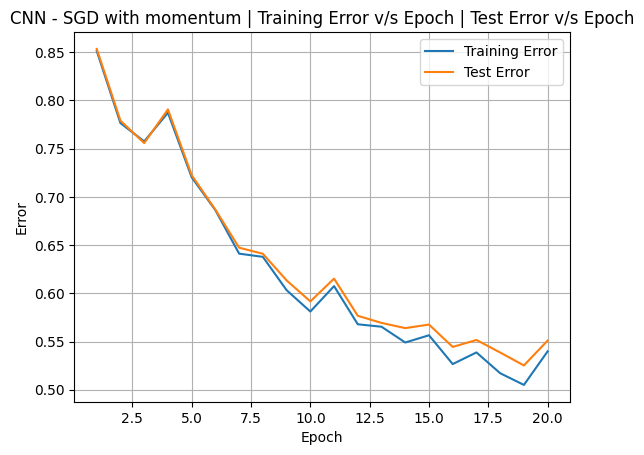

In [15]:
# CNN Table 6 - SGD with momentum
def train_cnn_sgdm_step(params, mean_g, x, y, lr, beta):
    def loss_fn(p):
        return cnn_loss_func(p, x, y)
    loss, grads = jax.value_and_grad(loss_fn)(params)
    new_mean_g = {}
    new_params = {}
    for name in params.keys():
        mg = (1.0-beta)*mean_g[name]+grads[name]*beta
        w_new = params[name] - lr * mg
        new_mean_g[name] = mg
        new_params[name] = w_new
    return new_params, new_mean_g, loss

def fit_sgdm_cnn(train_x, train_y, test_x, test_y, lr, beta=0.9, epochs=20, batch_size=64, seed=0):
    key = jax.random.PRNGKey(seed)
    params = init_cnn_params(key)
    mean_g = {k: jnp.zeros_like(v) for k, v in params.items()}
    train_errors=[]
    test_errors=[]
    for epoch in range(epochs):
        rng = np.random.default_rng(seed + epoch)
        for xn, yn in mini_batch(train_x, train_y, batch_size, rng):
            xn = jnp.array(xn)
            yn = jnp.array(yn)
            params, mean_g, loss = train_cnn_sgdm_step(params, mean_g, xn, yn, lr, beta)
        
        train_accuracy = float(cnn_accuracy(params, jnp.array(train_x), jnp.array(train_y)))
        train_errors.append(1-train_accuracy)
        test_accuracy = float(cnn_accuracy(params, jnp.array(test_x), jnp.array(test_y)))
        test_errors.append(1-test_accuracy)
        print(f"[CNN - SGDM] epoch={epoch+1:02d} | loss={float(loss):.4f} | test_accuracy={test_accuracy:.4f}")
    return params, train_errors, test_errors

# CNN Table 6 - SGDM
train_x_cnn = train_x.reshape(-1, 1, 32, 32)
test_x_cnn  = test_x.reshape(-1, 1, 32, 32)
params, train_errors, test_errors = fit_sgdm_cnn(train_x_cnn, train_y, test_x_cnn, test_y, lr=0.005)
plot_errors(train_errors, test_errors, "CNN - SGD with momentum | Training Error v/s Epoch | Test Error v/s Epoch")

In [17]:
np.save("saved_models/cnn_table_6/sgdm_train.npy", np.array(train_errors))
np.save("saved_models/cnn_table_6/sgdm_test.npy",  np.array(test_errors))
np.savez("saved_models/cnn_table_6/sgdm_model",
        layer1_conv_W=np.array(params["layer1_conv_W"]), layer1_conv_b=np.array(params["layer1_conv_b"]),
        layer3_conv_W=np.array(params["layer3_conv_W"]), layer3_conv_b=np.array(params["layer3_conv_b"]),
        output_fc_W=np.array(params["output_fc_W"]), output_fc_b=np.array(params["output_fc_b"]),)

[CNN - Adam] epoch=01 | loss=2.0523 | test_accuracy=0.4694
[CNN - Adam] epoch=02 | loss=1.0849 | test_accuracy=0.5611
[CNN - Adam] epoch=03 | loss=1.3323 | test_accuracy=0.5922
[CNN - Adam] epoch=04 | loss=1.0395 | test_accuracy=0.6069
[CNN - Adam] epoch=05 | loss=1.2088 | test_accuracy=0.6140
[CNN - Adam] epoch=06 | loss=0.9638 | test_accuracy=0.6341
[CNN - Adam] epoch=07 | loss=1.0981 | test_accuracy=0.6315
[CNN - Adam] epoch=08 | loss=1.0181 | test_accuracy=0.6493
[CNN - Adam] epoch=09 | loss=0.5276 | test_accuracy=0.6523
[CNN - Adam] epoch=10 | loss=0.5971 | test_accuracy=0.6654
[CNN - Adam] epoch=11 | loss=0.7788 | test_accuracy=0.6729
[CNN - Adam] epoch=12 | loss=0.7558 | test_accuracy=0.6657
[CNN - Adam] epoch=13 | loss=0.7024 | test_accuracy=0.6761
[CNN - Adam] epoch=14 | loss=0.9923 | test_accuracy=0.6800
[CNN - Adam] epoch=15 | loss=0.5919 | test_accuracy=0.6678
[CNN - Adam] epoch=16 | loss=0.6377 | test_accuracy=0.6715
[CNN - Adam] epoch=17 | loss=0.4060 | test_accuracy=0.67

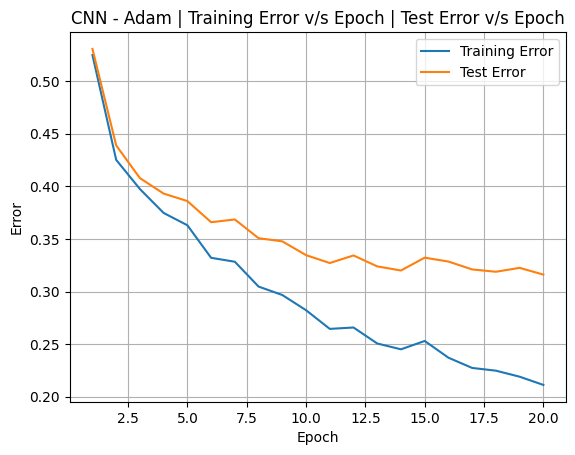

In [18]:
# CNN Table 6 - Adam
def train_cnn_adam_step(params, mean_g, mean_g2, x, y, lr, beta1, beta2, eps=1e-7):
    def loss_fn(p):
        return cnn_loss_func(p, x, y)
    loss, grads = jax.value_and_grad(loss_fn)(params)

    new_params = {}
    new_mean_g = {}
    new_mean_g2 = {}

    for name in params.keys():
        g = grads[name]
        mg = beta1*mean_g[name]+(1.0-beta1)*g
        mg2 = beta2*mean_g2[name]+(1.0-beta2)*(g*g)
        w_new = params[name]-lr* mg/(jnp.sqrt(mg2)+eps)

        new_params[name] = w_new
        new_mean_g[name] = mg
        new_mean_g2[name] = mg2

    return new_params, new_mean_g, new_mean_g2, loss

def fit_adam_cnn(train_x, train_y, test_x, test_y, lr, beta1=0.9, beta2=0.9, epochs=20, batch_size=64, seed=0):
    key = jax.random.PRNGKey(seed)
    params = init_cnn_params(key)
    mean_g = {k: jnp.zeros_like(v) for k, v in params.items()}
    mean_g2 = {k: jnp.zeros_like(v) for k, v in params.items()}

    train_errors=[]
    test_errors=[]

    for epoch in range(epochs):
        rng = np.random.default_rng(seed + epoch)
        for xn, yn in mini_batch(train_x, train_y, batch_size, rng):
            xn = jnp.array(xn)
            yn = jnp.array(yn)
            (params, mean_g, mean_g2, loss) = train_cnn_adam_step(params, mean_g, mean_g2, xn, yn, lr=lr, beta1=beta1, beta2=beta2)

        train_accuracy = float(cnn_accuracy(params, jnp.array(train_x), jnp.array(train_y)))
        train_errors.append(1-train_accuracy)
        test_accuracy = float(cnn_accuracy(params, jnp.array(test_x), jnp.array(test_y)))
        test_errors.append(1-test_accuracy)
        print(f"[CNN - Adam] epoch={epoch+1:02d} | loss={float(loss):.4f} | test_accuracy={test_accuracy:.4f}")

    return params, train_errors, test_errors

train_x_cnn = train_x.reshape(-1, 1, 32, 32)
test_x_cnn  = test_x.reshape(-1, 1, 32, 32)
params, train_errors, test_errors = fit_adam_cnn(train_x_cnn, train_y, test_x_cnn, test_y, lr=0.001)
plot_errors(train_errors, test_errors, "CNN - Adam | Training Error v/s Epoch | Test Error v/s Epoch")

In [19]:
np.save("saved_models/cnn_table_6/adam_train.npy", np.array(train_errors))
np.save("saved_models/cnn_table_6/adam_test.npy",  np.array(test_errors))
np.savez("saved_models/cnn_table_6/adam_model",
        layer1_conv_W=np.array(params["layer1_conv_W"]), layer1_conv_b=np.array(params["layer1_conv_b"]),
        layer3_conv_W=np.array(params["layer3_conv_W"]), layer3_conv_b=np.array(params["layer3_conv_b"]),
        output_fc_W=np.array(params["output_fc_W"]), output_fc_b=np.array(params["output_fc_b"]),)

In [6]:
## CNN (with dropout) - Table 7

def dropout_func(x, key, p=0.5, is_training=True):
    if not is_training:
        return x
    prob = 1.0-p
    mask = jax.random.bernoulli(key, prob, x.shape)
    return x*mask/prob

def cnn_forward_pass_dropout(params, x, key=None, dropout=0.5, is_training=True):
    h1  = conv_relu(x, params["layer1_conv_W"], params["layer1_conv_b"], stride=1)
    h1p = maxpool_2x2(h1)

    h2  = conv_relu(h1p, params["layer3_conv_W"], params["layer3_conv_b"], stride=1)
    h2p = maxpool_2x2(h2)

    flat = h2p.reshape(x.shape[0], -1)
    
    if key is None:
        # Test scenario
        flat = dropout_func(flat, jax.random.PRNGKey(0), p=dropout, is_training=False)
    else:
        flat = dropout_func(flat, key, p=dropout, is_training=is_training)
        
    logits = jnp.dot(flat, params["output_fc_W"]) + params["output_fc_b"]
    return logits

def cnn_loss_func_dropout(params, x, y, key, dropout):
    logits = cnn_forward_pass_dropout(params, x, key=key, dropout=dropout, is_training=True)
    log_prob = jax.nn.log_softmax(logits, axis=-1)
    neg_log_likelihood = -log_prob[jnp.arange(x.shape[0]), y]
    return neg_log_likelihood.mean()

def cnn_accuracy_dropout(params, x, y):
    logits = cnn_forward_pass_dropout(params, x, key=None, dropout=0.5, is_training=False)
    preds = jnp.argmax(logits, axis=-1)
    return (preds==y).mean()

[CNN - SGD] epoch=01 | loss=2.3585 | test_accuracy=0.2003
[CNN - SGD] epoch=02 | loss=2.0552 | test_accuracy=0.2648
[CNN - SGD] epoch=03 | loss=1.8848 | test_accuracy=0.2900
[CNN - SGD] epoch=04 | loss=2.2054 | test_accuracy=0.3297
[CNN - SGD] epoch=05 | loss=2.0260 | test_accuracy=0.3631
[CNN - SGD] epoch=06 | loss=1.9584 | test_accuracy=0.3399
[CNN - SGD] epoch=07 | loss=1.8011 | test_accuracy=0.4381
[CNN - SGD] epoch=08 | loss=1.6395 | test_accuracy=0.4209
[CNN - SGD] epoch=09 | loss=1.7700 | test_accuracy=0.4119
[CNN - SGD] epoch=10 | loss=1.4378 | test_accuracy=0.4631
[CNN - SGD] epoch=11 | loss=1.6637 | test_accuracy=0.3886
[CNN - SGD] epoch=12 | loss=1.2428 | test_accuracy=0.4745
[CNN - SGD] epoch=13 | loss=1.6805 | test_accuracy=0.4925
[CNN - SGD] epoch=14 | loss=1.7885 | test_accuracy=0.4906
[CNN - SGD] epoch=15 | loss=1.6446 | test_accuracy=0.4612
[CNN - SGD] epoch=16 | loss=1.7332 | test_accuracy=0.4835
[CNN - SGD] epoch=17 | loss=1.3781 | test_accuracy=0.4898
[CNN - SGD] ep

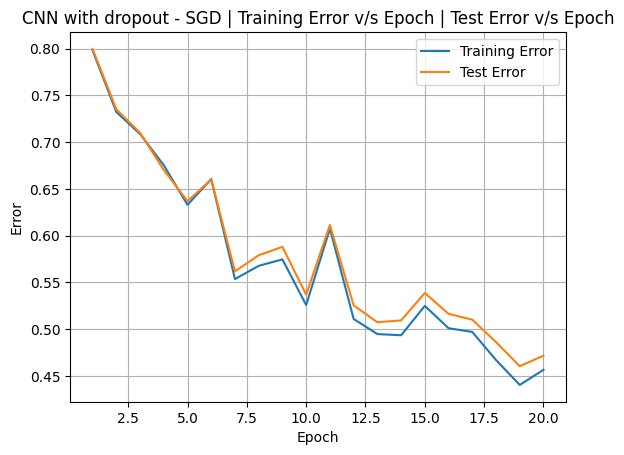

In [7]:
def train_cnn_sgd_step_dropout(params, x, y, lr, key, dropout):
    def loss_fn(p):
        return cnn_loss_func_dropout(p, x, y, key, dropout=dropout)
    loss, grads = jax.value_and_grad(loss_fn)(params)
    updated_params = {k: params[k]-lr*grads[k] for k in params.keys()}
    return updated_params, loss

def fit_sgd_cnn_dropout(train_x, train_y, test_x, test_y, lr, dropout, epochs=20, batch_size=64, seed=0):
    key = jax.random.PRNGKey(seed)
    params = init_cnn_params(key)

    train_errors = []
    test_errors = []
    
    for epoch in range(epochs):
        rng = np.random.default_rng(seed + epoch)
        for xn, yn in mini_batch(train_x, train_y, batch_size, rng):
            xn = jnp.array(xn)
            yn = jnp.array(yn)
            key, subkey = jax.random.split(key)
            params, loss = train_cnn_sgd_step_dropout(params, xn, yn, lr, subkey, dropout)

        train_accuracy = float(cnn_accuracy_dropout(params, jnp.array(train_x), jnp.array(train_y)))
        train_errors.append(1-train_accuracy)
        test_accuracy = float(cnn_accuracy_dropout(params, jnp.array(test_x), jnp.array(test_y)))
        test_errors.append(1-test_accuracy)
        print(f"[CNN - SGD] epoch={epoch+1:02d} | loss={float(loss):.4f} | test_accuracy={test_accuracy:.4f}")
    return params, train_errors, test_errors

# CNN with dropout - SGD
train_x_cnn = train_x.reshape(-1, 1, 32, 32)
test_x_cnn  = test_x.reshape(-1, 1, 32, 32)
params, train_errors, test_errors = fit_sgd_cnn_dropout(train_x_cnn, train_y, test_x_cnn, test_y, lr=0.01, dropout=0.5)
plot_errors(train_errors, test_errors, "CNN with dropout - SGD | Training Error v/s Epoch | Test Error v/s Epoch")

In [33]:
os.makedirs("saved_models/cnn_table_7")
np.save("saved_models/cnn_table_7/sgd_train.npy", np.array(train_errors))
np.save("saved_models/cnn_table_7/sgd_test.npy",  np.array(test_errors))
np.savez("saved_models/cnn_table_7/sgd_model",
        layer1_conv_W=np.array(params["layer1_conv_W"]), layer1_conv_b=np.array(params["layer1_conv_b"]),
        layer3_conv_W=np.array(params["layer3_conv_W"]), layer3_conv_b=np.array(params["layer3_conv_b"]),
        output_fc_W=np.array(params["output_fc_W"]), output_fc_b=np.array(params["output_fc_b"]),)

[CNN with dropout - SGDM] epoch=01 | loss=2.3076 | test_accuracy=0.1509
[CNN with dropout - SGDM] epoch=02 | loss=2.2046 | test_accuracy=0.2101
[CNN with dropout - SGDM] epoch=03 | loss=1.9456 | test_accuracy=0.2394
[CNN with dropout - SGDM] epoch=04 | loss=2.3475 | test_accuracy=0.2644
[CNN with dropout - SGDM] epoch=05 | loss=2.3091 | test_accuracy=0.2764
[CNN with dropout - SGDM] epoch=06 | loss=2.3004 | test_accuracy=0.3128
[CNN with dropout - SGDM] epoch=07 | loss=2.0530 | test_accuracy=0.3374
[CNN with dropout - SGDM] epoch=08 | loss=1.8722 | test_accuracy=0.3655
[CNN with dropout - SGDM] epoch=09 | loss=1.6659 | test_accuracy=0.3867
[CNN with dropout - SGDM] epoch=10 | loss=1.6959 | test_accuracy=0.4093
[CNN with dropout - SGDM] epoch=11 | loss=1.7773 | test_accuracy=0.4108
[CNN with dropout - SGDM] epoch=12 | loss=1.3993 | test_accuracy=0.4264
[CNN with dropout - SGDM] epoch=13 | loss=1.8513 | test_accuracy=0.4373
[CNN with dropout - SGDM] epoch=14 | loss=1.8222 | test_accuracy

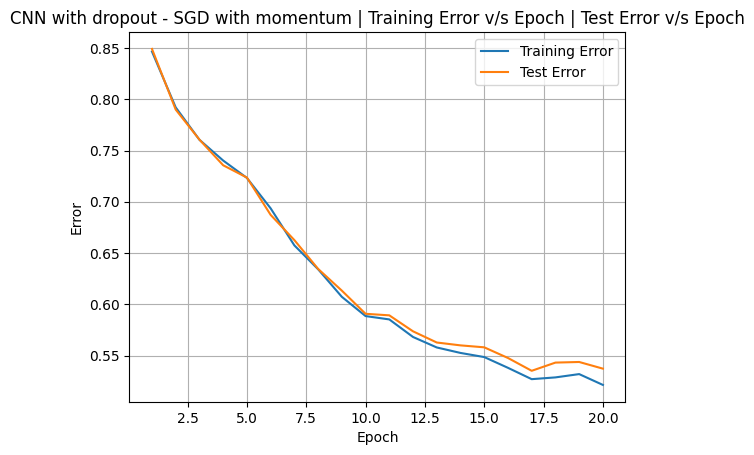

In [37]:
# CNN with dropout Table 7 - SGD with momentum
def train_cnn_sgdm_step_dropout(params, mean_g, x, y, lr, beta, key, dropout):
    def loss_fn(p):
        return cnn_loss_func_dropout(p, x, y, key, dropout=dropout)
    loss, grads = jax.value_and_grad(loss_fn)(params)
    new_mean_g = {}
    new_params = {}
    for name in params.keys():
        mg = (1.0-beta)*mean_g[name]+grads[name]*beta
        w_new = params[name] - lr * mg
        new_mean_g[name] = mg
        new_params[name] = w_new
    return new_params, new_mean_g, loss

def fit_sgdm_cnn_dropout(train_x, train_y, test_x, test_y, lr, dropout, beta=0.9, epochs=20, batch_size=64, seed=0):
    key = jax.random.PRNGKey(seed)
    params = init_cnn_params(key)
    mean_g = {k: jnp.zeros_like(v) for k, v in params.items()}
    train_errors=[]
    test_errors=[]
    for epoch in range(epochs):
        rng = np.random.default_rng(seed + epoch)
        for xn, yn in mini_batch(train_x, train_y, batch_size, rng):
            xn = jnp.array(xn)
            yn = jnp.array(yn)
            key, subkey = jax.random.split(key)
            params, mean_g, loss = train_cnn_sgdm_step_dropout(params, mean_g, xn, yn, lr, beta, subkey, dropout)
        
        train_accuracy = float(cnn_accuracy_dropout(params, jnp.array(train_x), jnp.array(train_y)))
        train_errors.append(1-train_accuracy)
        test_accuracy = float(cnn_accuracy_dropout(params, jnp.array(test_x), jnp.array(test_y)))
        test_errors.append(1-test_accuracy)
        print(f"[CNN with dropout - SGDM] epoch={epoch+1:02d} | loss={float(loss):.4f} | test_accuracy={test_accuracy:.4f}")
    return params, train_errors, test_errors

# CNN Table 7 - SGDM
train_x_cnn = train_x.reshape(-1, 1, 32, 32)
test_x_cnn  = test_x.reshape(-1, 1, 32, 32)
params, train_errors, test_errors = fit_sgdm_cnn_dropout(train_x_cnn, train_y, test_x_cnn, test_y, lr=0.005, dropout=0.5)
plot_errors(train_errors, test_errors, "CNN with dropout - SGD with momentum | Training Error v/s Epoch | Test Error v/s Epoch")

In [38]:
np.save("saved_models/cnn_table_7/sgdm_train.npy", np.array(train_errors))
np.save("saved_models/cnn_table_7/sgdm_test.npy",  np.array(test_errors))
np.savez("saved_models/cnn_table_7/sgdm_model",
        layer1_conv_W=np.array(params["layer1_conv_W"]), layer1_conv_b=np.array(params["layer1_conv_b"]),
        layer3_conv_W=np.array(params["layer3_conv_W"]), layer3_conv_b=np.array(params["layer3_conv_b"]),
        output_fc_W=np.array(params["output_fc_W"]), output_fc_b=np.array(params["output_fc_b"]),)

[CNN - Adam] epoch=01 | loss=2.1508 | test_accuracy=0.4620
[CNN - Adam] epoch=02 | loss=1.1636 | test_accuracy=0.5254
[CNN - Adam] epoch=03 | loss=1.4162 | test_accuracy=0.5635
[CNN - Adam] epoch=04 | loss=1.3612 | test_accuracy=0.5879
[CNN - Adam] epoch=05 | loss=1.3605 | test_accuracy=0.6175
[CNN - Adam] epoch=06 | loss=1.0785 | test_accuracy=0.6033
[CNN - Adam] epoch=07 | loss=1.2454 | test_accuracy=0.6303
[CNN - Adam] epoch=08 | loss=0.9442 | test_accuracy=0.6379
[CNN - Adam] epoch=09 | loss=0.6991 | test_accuracy=0.6520
[CNN - Adam] epoch=10 | loss=0.7087 | test_accuracy=0.6577
[CNN - Adam] epoch=11 | loss=0.9028 | test_accuracy=0.6654
[CNN - Adam] epoch=12 | loss=1.2408 | test_accuracy=0.6711
[CNN - Adam] epoch=13 | loss=0.9509 | test_accuracy=0.6700
[CNN - Adam] epoch=14 | loss=1.3899 | test_accuracy=0.6751
[CNN - Adam] epoch=15 | loss=0.8173 | test_accuracy=0.6690
[CNN - Adam] epoch=16 | loss=0.8281 | test_accuracy=0.6806
[CNN - Adam] epoch=17 | loss=1.1318 | test_accuracy=0.68

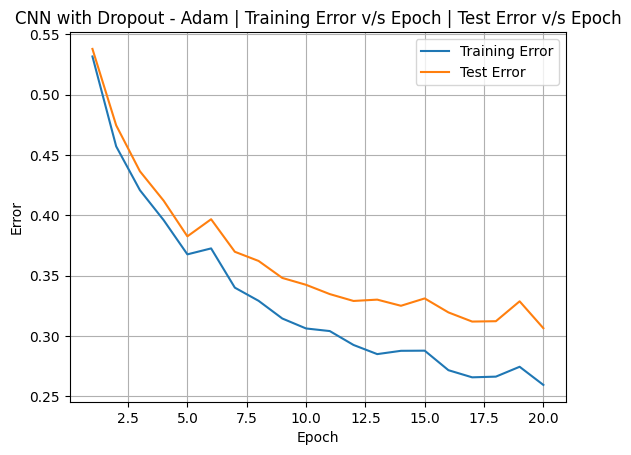

In [42]:
# CNN with dropout Table 7 - Adam
def train_cnn_adam_step_dropout(params, mean_g, mean_g2, x, y, lr, beta1, beta2, key, dropout, eps=1e-7):
    def loss_fn(p):
        return cnn_loss_func_dropout(p, x, y, key, dropout=dropout)
    loss, grads = jax.value_and_grad(loss_fn)(params)

    new_params = {}
    new_mean_g = {}
    new_mean_g2 = {}

    for name in params.keys():
        g = grads[name]
        mg = beta1*mean_g[name]+(1.0-beta1)*g
        mg2 = beta2*mean_g2[name]+(1.0-beta2)*(g*g)
        w_new = params[name]-lr* mg/(jnp.sqrt(mg2)+eps)

        new_params[name] = w_new
        new_mean_g[name] = mg
        new_mean_g2[name] = mg2

    return new_params, new_mean_g, new_mean_g2, loss

def fit_adam_cnn_dropout(train_x, train_y, test_x, test_y, lr, dropout, beta1=0.9, beta2=0.9, epochs=20, batch_size=64, seed=0):
    key = jax.random.PRNGKey(seed)
    params = init_cnn_params(key)
    mean_g = {k: jnp.zeros_like(v) for k, v in params.items()}
    mean_g2 = {k: jnp.zeros_like(v) for k, v in params.items()}

    train_errors=[]
    test_errors=[]

    for epoch in range(epochs):
        rng = np.random.default_rng(seed + epoch)
        for xn, yn in mini_batch(train_x, train_y, batch_size, rng):
            xn = jnp.array(xn)
            yn = jnp.array(yn)
            key, subkey = jax.random.split(key)
            (params, mean_g, mean_g2, loss) = train_cnn_adam_step_dropout(params, mean_g, mean_g2, xn, yn, lr=lr, beta1=beta1, beta2=beta2, key=subkey, dropout=dropout)

        train_accuracy = float(cnn_accuracy_dropout(params, jnp.array(train_x), jnp.array(train_y)))
        train_errors.append(1-train_accuracy)
        test_accuracy = float(cnn_accuracy_dropout(params, jnp.array(test_x), jnp.array(test_y)))
        test_errors.append(1-test_accuracy)
        print(f"[CNN - Adam] epoch={epoch+1:02d} | loss={float(loss):.4f} | test_accuracy={test_accuracy:.4f}")

    return params, train_errors, test_errors

train_x_cnn = train_x.reshape(-1, 1, 32, 32)
test_x_cnn  = test_x.reshape(-1, 1, 32, 32)
params, train_errors, test_errors = fit_adam_cnn_dropout(train_x_cnn, train_y, test_x_cnn, test_y, lr=0.001, dropout=0.5)
plot_errors(train_errors, test_errors, "CNN with Dropout - Adam | Training Error v/s Epoch | Test Error v/s Epoch")

In [44]:
np.save("saved_models/cnn_table_7/adam_train.npy", np.array(train_errors))
np.save("saved_models/cnn_table_7/adam_test.npy",  np.array(test_errors))
np.savez("saved_models/cnn_table_7/adam_model",
        layer1_conv_W=np.array(params["layer1_conv_W"]), layer1_conv_b=np.array(params["layer1_conv_b"]),
        layer3_conv_W=np.array(params["layer3_conv_W"]), layer3_conv_b=np.array(params["layer3_conv_b"]),
        output_fc_W=np.array(params["output_fc_W"]), output_fc_b=np.array(params["output_fc_b"]),)

In [6]:
#Table 8 - VGG
def init_vgg_params(key, num_classes=10):
    k1, k2, k3, k4, k5 = jax.random.split(key, 5)

    #Layer 1
    conv1_shape = (32, 1, 3, 3)
    conv1_n_in  = 1*3*3
    conv1_n_out = 32*3*3
    conv1_std   = 1.0/jnp.sqrt(conv1_n_in+conv1_n_out)
    layer1_conv_W = conv1_std*jax.random.normal(k1, conv1_shape)
    layer1_conv_b = jnp.zeros((32,))

    #Layer 2
    conv2_shape = (32, 32, 3, 3)
    conv2_n_in  = 32*3*3
    conv2_n_out = 32*3*3
    conv2_std   = 1.0/jnp.sqrt(conv2_n_in + conv2_n_out)
    layer2_conv_W = conv2_std*jax.random.normal(k2, conv2_shape)
    layer2_conv_b = jnp.zeros((32,))

    #Layer 4
    conv3_shape = (64, 32, 3, 3)
    conv3_n_in  = 32*3*3
    conv3_n_out = 64*3*3
    conv3_std   = 1.0/jnp.sqrt(conv3_n_in+conv3_n_out)
    layer4_conv_W = conv3_std*jax.random.normal(k3, conv3_shape)
    layer4_conv_b = jnp.zeros((64,))

    #Layer 5
    conv4_shape = (64, 64, 3, 3)
    conv4_n_in  = 64*3*3
    conv4_n_out = 64*3*3
    conv4_std   = 1.0/jnp.sqrt(conv4_n_in + conv4_n_out)
    layer5_conv_W = conv4_std*jax.random.normal(k4, conv4_shape)
    layer5_conv_b = jnp.zeros((64,))

    fc_in  = 64*8*8
    fc_out = num_classes
    fc_std = 1.0/jnp.sqrt(fc_in+fc_out)
    output_fc_W = fc_std*jax.random.normal(k5, (fc_in, fc_out))
    output_fc_b = jnp.zeros((fc_out,))
    return {
        "layer1_conv_W": layer1_conv_W,
        "layer1_conv_b": layer1_conv_b,
        "layer2_conv_W": layer2_conv_W,
        "layer2_conv_b": layer2_conv_b,
        "layer4_conv_W": layer4_conv_W,
        "layer4_conv_b": layer4_conv_b,
        "layer5_conv_W": layer5_conv_W,
        "layer5_conv_b": layer5_conv_b,
        "output_fc_W": output_fc_W,
        "output_fc_b": output_fc_b,
    }

def vgg_forward_pass(params, x, key=None, dropout=0.5, is_training=True):
    h1  = conv_relu(x, params["layer1_conv_W"], params["layer1_conv_b"], stride=1)
    h2  = conv_relu(h1, params["layer2_conv_W"], params["layer2_conv_b"], stride=1)
    h2p = maxpool_2x2(h2)
    h3  = conv_relu(h2p, params["layer4_conv_W"], params["layer4_conv_b"], stride=1)
    h4  = conv_relu(h3, params["layer5_conv_W"], params["layer5_conv_b"], stride=1)
    h4p = maxpool_2x2(h4)

    flat = h4p.reshape(x.shape[0], -1)
    if key is None:
        # Test scenario
        flat = dropout_func(flat, jax.random.PRNGKey(0), p=dropout, is_training=False)
    else:
        flat = dropout_func(flat, key, p=dropout, is_training=is_training)
        
    logits = jnp.dot(flat, params["output_fc_W"]) + params["output_fc_b"]
    return logits

def vgg_loss_func(params, x, y, key, dropout):
    logits = vgg_forward_pass(params, x, key=key, dropout=dropout, is_training=True)
    log_prob = jax.nn.log_softmax(logits, axis=-1)
    neg_log_likelihood = -log_prob[jnp.arange(x.shape[0]), y]
    return neg_log_likelihood.mean()

def vgg_accuracy(params, x, y):
    logits = vgg_forward_pass(params, x, key=None, dropout=0.5, is_training=False)
    preds = jnp.argmax(logits, axis=-1)
    return (preds==y).mean()

[VGG - SGD] epoch=01 | loss=2.2999 | test_accuracy=0.1209
[VGG - SGD] epoch=02 | loss=2.0802 | test_accuracy=0.2374
[VGG - SGD] epoch=03 | loss=2.0206 | test_accuracy=0.2626
[VGG - SGD] epoch=04 | loss=2.3528 | test_accuracy=0.2188
[VGG - SGD] epoch=05 | loss=2.0114 | test_accuracy=0.3686
[VGG - SGD] epoch=06 | loss=1.7509 | test_accuracy=0.2750
[VGG - SGD] epoch=07 | loss=1.8354 | test_accuracy=0.4270
[VGG - SGD] epoch=08 | loss=1.6131 | test_accuracy=0.4471
[VGG - SGD] epoch=09 | loss=1.4185 | test_accuracy=0.4376
[VGG - SGD] epoch=10 | loss=1.2058 | test_accuracy=0.4814
[VGG - SGD] epoch=11 | loss=1.5657 | test_accuracy=0.4334
[VGG - SGD] epoch=12 | loss=1.4804 | test_accuracy=0.5173
[VGG - SGD] epoch=13 | loss=1.7973 | test_accuracy=0.5135
[VGG - SGD] epoch=14 | loss=1.6568 | test_accuracy=0.5380
[VGG - SGD] epoch=15 | loss=1.5083 | test_accuracy=0.5225
[VGG - SGD] epoch=16 | loss=1.2582 | test_accuracy=0.5513
[VGG - SGD] epoch=17 | loss=1.0795 | test_accuracy=0.5625
[VGG - SGD] ep

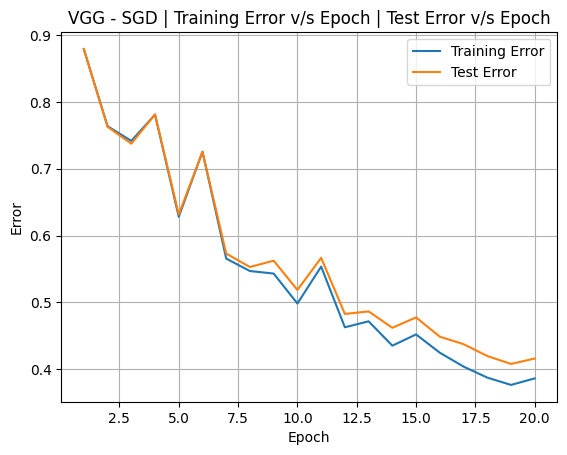

In [12]:
# Table 8 VGG - SGD
def train_vgg_sgd_step(params, x, y, lr, key, dropout):
    def loss_fn(p):
        return vgg_loss_func(p, x, y, key, dropout=dropout)
    loss, grads = jax.value_and_grad(loss_fn)(params)
    updated_params = {k: params[k]-lr*grads[k] for k in params.keys()}
    return updated_params, loss

def fit_sgd_vgg(train_x, train_y, test_x, test_y, lr, dropout, epochs=20, batch_size=64, seed=0):
    key = jax.random.PRNGKey(seed)
    params = init_vgg_params(key)

    train_errors = []
    test_errors = []
    
    for epoch in range(epochs):
        rng = np.random.default_rng(seed + epoch)
        for xn, yn in mini_batch(train_x, train_y, batch_size, rng):
            xn = jnp.array(xn)
            yn = jnp.array(yn)
            key, subkey = jax.random.split(key)
            params, loss = train_vgg_sgd_step(params, xn, yn, lr, subkey, dropout)

        train_accuracy = float(vgg_accuracy(params, jnp.array(train_x), jnp.array(train_y)))
        train_errors.append(1-train_accuracy)
        test_accuracy = float(vgg_accuracy(params, jnp.array(test_x), jnp.array(test_y)))
        test_errors.append(1-test_accuracy)
        print(f"[VGG - SGD] epoch={epoch+1:02d} | loss={float(loss):.4f} | test_accuracy={test_accuracy:.4f}")
    return params, train_errors, test_errors

# Table 8 VGG - SGD
train_x_vgg = train_x.reshape(-1, 1, 32, 32)
test_x_vgg  = test_x.reshape(-1, 1, 32, 32)
params, train_errors, test_errors = fit_sgd_vgg(train_x_vgg, train_y, test_x_vgg, test_y, lr=0.01, dropout=0.5)
plot_errors(train_errors, test_errors, "VGG - SGD | Training Error v/s Epoch | Test Error v/s Epoch")

In [14]:
os.makedirs("saved_models/vgg_table_8", exist_ok=True)
np.save("saved_models/vgg_table_8/sgd_train.npy", np.array(train_errors))
np.save("saved_models/vgg_table_8/sgd_test.npy",  np.array(test_errors))
np.savez("saved_models/vgg_table_8/sgd_model",
        layer1_conv_W=np.array(params["layer1_conv_W"]), layer1_conv_b=np.array(params["layer1_conv_b"]),
        layer2_conv_W=np.array(params["layer2_conv_W"]), layer2_conv_b=np.array(params["layer2_conv_b"]),
        layer4_conv_W=np.array(params["layer4_conv_W"]), layer4_conv_b=np.array(params["layer4_conv_b"]),
        layer5_conv_W=np.array(params["layer5_conv_W"]), layer5_conv_b=np.array(params["layer5_conv_b"]),
        output_fc_W=np.array(params["output_fc_W"]), output_fc_b=np.array(params["output_fc_b"]),)

[VGG - SGDM] epoch=01 | loss=2.3003 | test_accuracy=0.1203
[VGG - SGDM] epoch=02 | loss=2.0805 | test_accuracy=0.2375
[VGG - SGDM] epoch=03 | loss=2.0177 | test_accuracy=0.2649
[VGG - SGDM] epoch=04 | loss=2.3534 | test_accuracy=0.2353
[VGG - SGDM] epoch=05 | loss=2.0068 | test_accuracy=0.3694
[VGG - SGDM] epoch=06 | loss=1.7419 | test_accuracy=0.2817
[VGG - SGDM] epoch=07 | loss=1.8427 | test_accuracy=0.4301
[VGG - SGDM] epoch=08 | loss=1.6093 | test_accuracy=0.4456
[VGG - SGDM] epoch=09 | loss=1.4193 | test_accuracy=0.4462
[VGG - SGDM] epoch=10 | loss=1.2233 | test_accuracy=0.4846
[VGG - SGDM] epoch=11 | loss=1.5565 | test_accuracy=0.4514
[VGG - SGDM] epoch=12 | loss=1.5053 | test_accuracy=0.5180
[VGG - SGDM] epoch=13 | loss=1.7854 | test_accuracy=0.5244
[VGG - SGDM] epoch=14 | loss=1.6620 | test_accuracy=0.5400
[VGG - SGDM] epoch=15 | loss=1.4980 | test_accuracy=0.5289
[VGG - SGDM] epoch=16 | loss=1.2744 | test_accuracy=0.5552
[VGG - SGDM] epoch=17 | loss=1.0703 | test_accuracy=0.56

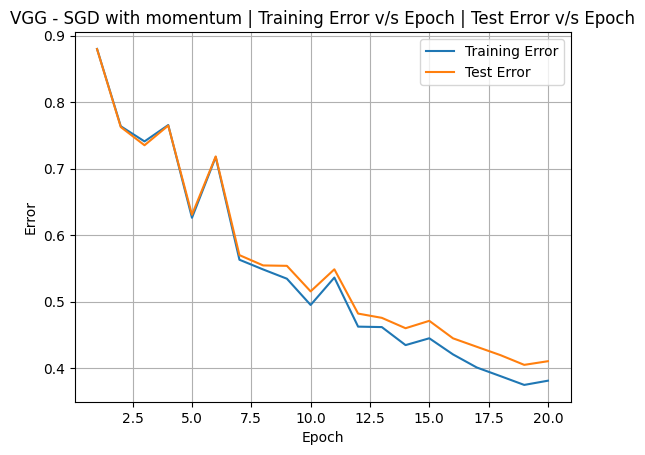

In [15]:
# VGG Table 8 - SGD with momentum
def train_vgg_sgdm_step(params, mean_g, x, y, lr, beta, key, dropout):
    def loss_fn(p):
        return vgg_loss_func(p, x, y, key, dropout=dropout)
    loss, grads = jax.value_and_grad(loss_fn)(params)
    new_mean_g = {}
    new_params = {}
    for name in params.keys():
        mg = (1.0-beta)*mean_g[name]+grads[name]*beta
        w_new = params[name] - lr * mg
        new_mean_g[name] = mg
        new_params[name] = w_new
    return new_params, new_mean_g, loss

def fit_sgdm_vgg(train_x, train_y, test_x, test_y, lr, dropout, beta=0.9, epochs=20, batch_size=64, seed=0):
    key = jax.random.PRNGKey(seed)
    params = init_vgg_params(key)
    mean_g = {k: jnp.zeros_like(v) for k, v in params.items()}
    train_errors=[]
    test_errors=[]
    for epoch in range(epochs):
        rng = np.random.default_rng(seed + epoch)
        for xn, yn in mini_batch(train_x, train_y, batch_size, rng):
            xn = jnp.array(xn)
            yn = jnp.array(yn)
            key, subkey = jax.random.split(key)
            params, mean_g, loss = train_vgg_sgdm_step(params, mean_g, xn, yn, lr, beta, subkey, dropout)
        
        train_accuracy = float(vgg_accuracy(params, jnp.array(train_x), jnp.array(train_y)))
        train_errors.append(1-train_accuracy)
        test_accuracy = float(vgg_accuracy(params, jnp.array(test_x), jnp.array(test_y)))
        test_errors.append(1-test_accuracy)
        print(f"[VGG - SGDM] epoch={epoch+1:02d} | loss={float(loss):.4f} | test_accuracy={test_accuracy:.4f}")
    return params, train_errors, test_errors

# VGG Table 8 - SGDM
train_x_vgg = train_x.reshape(-1, 1, 32, 32)
test_x_vgg  = test_x.reshape(-1, 1, 32, 32)
params, train_errors, test_errors = fit_sgdm_vgg(train_x_vgg, train_y, test_x_vgg, test_y, lr=0.01, dropout=0.5)
plot_errors(train_errors, test_errors, "VGG - SGD with momentum | Training Error v/s Epoch | Test Error v/s Epoch")

In [16]:
np.save("saved_models/vgg_table_8/sgdm_train.npy", np.array(train_errors))
np.save("saved_models/vgg_table_8/sgdm_test.npy",  np.array(test_errors))
np.savez("saved_models/vgg_table_8/sgdm_model",
        layer1_conv_W=np.array(params["layer1_conv_W"]), layer1_conv_b=np.array(params["layer1_conv_b"]),
        layer2_conv_W=np.array(params["layer2_conv_W"]), layer2_conv_b=np.array(params["layer2_conv_b"]),
        layer4_conv_W=np.array(params["layer4_conv_W"]), layer4_conv_b=np.array(params["layer4_conv_b"]),
        layer5_conv_W=np.array(params["layer5_conv_W"]), layer5_conv_b=np.array(params["layer5_conv_b"]),
        output_fc_W=np.array(params["output_fc_W"]), output_fc_b=np.array(params["output_fc_b"]),)

[VGG - Adam] epoch=01 | loss=2.1767 | test_accuracy=0.4174
[VGG - Adam] epoch=02 | loss=1.4589 | test_accuracy=0.4752
[VGG - Adam] epoch=03 | loss=1.1962 | test_accuracy=0.4856
[VGG - Adam] epoch=04 | loss=1.7532 | test_accuracy=0.5217
[VGG - Adam] epoch=05 | loss=1.5478 | test_accuracy=0.5389
[VGG - Adam] epoch=06 | loss=1.2050 | test_accuracy=0.5423
[VGG - Adam] epoch=07 | loss=1.7345 | test_accuracy=0.5502
[VGG - Adam] epoch=08 | loss=1.0802 | test_accuracy=0.5746
[VGG - Adam] epoch=09 | loss=1.2323 | test_accuracy=0.5858
[VGG - Adam] epoch=10 | loss=1.0317 | test_accuracy=0.5948
[VGG - Adam] epoch=11 | loss=1.1722 | test_accuracy=0.6010
[VGG - Adam] epoch=12 | loss=1.1077 | test_accuracy=0.6087
[VGG - Adam] epoch=13 | loss=1.3149 | test_accuracy=0.6067
[VGG - Adam] epoch=14 | loss=1.1944 | test_accuracy=0.6239
[VGG - Adam] epoch=15 | loss=1.0442 | test_accuracy=0.6078
[VGG - Adam] epoch=16 | loss=0.8756 | test_accuracy=0.6264
[VGG - Adam] epoch=17 | loss=0.6849 | test_accuracy=0.63

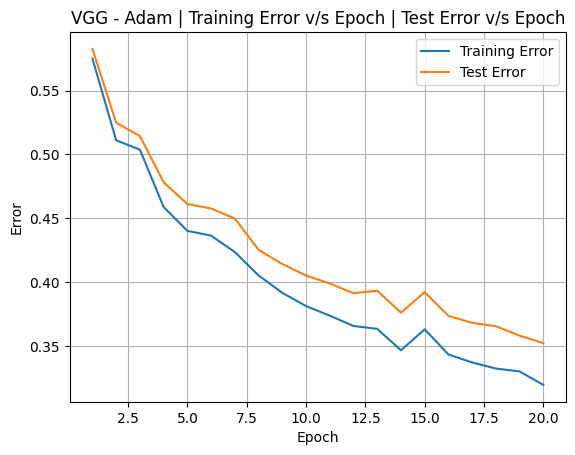

In [10]:
# VGG Table 8 - Adam
def train_vgg_adam_step(params, mean_g, mean_g2, x, y, lr, beta1, beta2, key, dropout, eps=1e-9):
    def loss_fn(p):
        return vgg_loss_func(p, x, y, key, dropout=dropout)
    loss, grads = jax.value_and_grad(loss_fn)(params)

    new_params = {}
    new_mean_g = {}
    new_mean_g2 = {}

    for name in params.keys():
        g = grads[name]
        mg = beta1*mean_g[name]+(1.0-beta1)*g
        mg2 = beta2*mean_g2[name]+(1.0-beta2)*(g*g)
        w_new = params[name]-lr* mg/(jnp.sqrt(mg2)+eps)

        new_params[name] = w_new
        new_mean_g[name] = mg
        new_mean_g2[name] = mg2

    return new_params, new_mean_g, new_mean_g2, loss

def fit_adam_vgg(train_x, train_y, test_x, test_y, lr, dropout, beta1=0.9, beta2=0.999, epochs=20, batch_size=64, seed=0):
    key = jax.random.PRNGKey(seed)
    params = init_vgg_params(key)
    mean_g = {k: jnp.zeros_like(v) for k, v in params.items()}
    mean_g2 = {k: jnp.zeros_like(v) for k, v in params.items()}

    train_errors=[]
    test_errors=[]

    for epoch in range(epochs):
        rng = np.random.default_rng(seed + epoch)
        for xn, yn in mini_batch(train_x, train_y, batch_size, rng):
            xn = jnp.array(xn)
            yn = jnp.array(yn)
            key, subkey = jax.random.split(key)
            (params, mean_g, mean_g2, loss) = train_vgg_adam_step(params, mean_g, mean_g2, xn, yn, lr=lr, beta1=beta1, beta2=beta2, key=subkey, dropout=dropout)

        train_accuracy = float(vgg_accuracy(params, jnp.array(train_x), jnp.array(train_y)))
        train_errors.append(1-train_accuracy)
        test_accuracy = float(vgg_accuracy(params, jnp.array(test_x), jnp.array(test_y)))
        test_errors.append(1-test_accuracy)
        print(f"[VGG - Adam] epoch={epoch+1:02d} | loss={float(loss):.4f} | test_accuracy={test_accuracy:.4f}")

    return params, train_errors, test_errors

train_x_vgg = train_x.reshape(-1, 1, 32, 32)
test_x_vgg  = test_x.reshape(-1, 1, 32, 32)
params, train_errors, test_errors = fit_adam_vgg(train_x_vgg, train_y, test_x_vgg, test_y, lr=0.001, dropout=0.5)
plot_errors(train_errors, test_errors, "VGG - Adam | Training Error v/s Epoch | Test Error v/s Epoch")

In [11]:
np.save("saved_models/vgg_table_8/adam_train.npy", np.array(train_errors))
np.save("saved_models/vgg_table_8/adam_test.npy",  np.array(test_errors))
np.savez("saved_models/vgg_table_8/adam_model",
        layer1_conv_W=np.array(params["layer1_conv_W"]), layer1_conv_b=np.array(params["layer1_conv_b"]),
        layer2_conv_W=np.array(params["layer2_conv_W"]), layer2_conv_b=np.array(params["layer2_conv_b"]),
        layer4_conv_W=np.array(params["layer4_conv_W"]), layer4_conv_b=np.array(params["layer4_conv_b"]),
        layer5_conv_W=np.array(params["layer5_conv_W"]), layer5_conv_b=np.array(params["layer5_conv_b"]),
        output_fc_W=np.array(params["output_fc_W"]), output_fc_b=np.array(params["output_fc_b"]),)

In [10]:
#Table 9 - ResNet
def init_resnet_params(key, num_classes=10):
    k1, k2, k3, k4, k5, k6, k7 = jax.random.split(key, 7)

    #Layer 1
    layer1_shape = (32, 1, 3, 3)
    layer1_std   = 1.0/jnp.sqrt(1*3*3+32*3*3)
    layer1_conv_W = layer1_std*jax.random.normal(k1, layer1_shape)
    layer1_conv_b = jnp.zeros((32,))

    #Layer 2
    layer2_shape = (32, 32, 3, 3)
    layer2_std   = 1.0/jnp.sqrt(32*3*3 + 32*3*3)
    layer2_conv_W = layer2_std*jax.random.normal(k2, layer2_shape)
    layer2_conv_b = jnp.zeros((32,))

     #Layer 3 -> Projection
    layer3_shape = (32, 1, 1, 1)
    layer3_std   = 1.0/jnp.sqrt(1+32)
    layer3_projection_W = layer3_std*jax.random.normal(k3, layer3_shape)
    layer3_projection_b = jnp.zeros((32,))

    #Layer 6
    layer6_shape = (64, 32, 3, 3)
    layer6_std   = 1.0/jnp.sqrt(32*3*3 + 64*3*3)
    layer6_conv_W = layer6_std*jax.random.normal(k4, layer6_shape)
    layer6_conv_b = jnp.zeros((64,))

    #Layer 7
    layer7_shape = (64, 64, 3, 3)
    layer7_std   = 1.0/jnp.sqrt(64*3*3 + 64*3*3)
    layer7_conv_W = layer7_std*jax.random.normal(k5, layer7_shape)
    layer7_conv_b = jnp.zeros((64,))

     #Layer 8 -> Projection
    layer8_shape = (64, 32, 1, 1)
    layer8_std   = 1.0/jnp.sqrt(32+64)
    layer8_projection_W = layer8_std*jax.random.normal(k6, layer8_shape)
    layer8_projection_b = jnp.zeros((64,))
    
    fc_in  = 64*8*8
    fc_out = num_classes
    fc_std = 1.0/jnp.sqrt(fc_in+fc_out)
    output_fc_W = fc_std*jax.random.normal(k7, (fc_in, fc_out))
    output_fc_b = jnp.zeros((fc_out,))
    return {
        "layer1_conv_W": layer1_conv_W,
        "layer1_conv_b": layer1_conv_b,
        "layer2_conv_W": layer2_conv_W,
        "layer2_conv_b": layer2_conv_b,
        "layer3_projection_W": layer3_projection_W,
        "layer3_projection_b": layer3_projection_b,
        
        "layer6_conv_W": layer6_conv_W,
        "layer6_conv_b": layer6_conv_b,
        "layer7_conv_W": layer7_conv_W,
        "layer7_conv_b": layer7_conv_b,
        "layer8_projection_W": layer8_projection_W,
        "layer8_projection_b": layer8_projection_b,
        
        "output_fc_W": output_fc_W,
        "output_fc_b": output_fc_b,
    }

def conv_lin(x, W, b, stride=1):
    y = lax.conv_general_dilated(x, W, window_strides=(stride, stride), padding="SAME", dimension_numbers=("NCHW", "OIHW", "NCHW"))
    return y + b.reshape(1, -1, 1, 1)

def resnet_forward_pass(params, x, key=None, dropout=0.5, is_training=True):
    h1  = conv_relu(x, params["layer1_conv_W"], params["layer1_conv_b"], stride=1)
    h2  = conv_lin(h1, params["layer2_conv_W"], params["layer2_conv_b"], stride=1)
    h3 = conv_lin(x, params["layer3_projection_W"], params["layer3_projection_b"], stride=1)
    h4 = jnp.maximum(h2+h3, 0.0)
    h4p = maxpool_2x2(h4)
    
    h5  = conv_relu(h4p, params["layer6_conv_W"], params["layer6_conv_b"], stride=1)
    h6  = conv_lin(h5, params["layer7_conv_W"], params["layer7_conv_b"], stride=1)
    h7 = conv_lin(h4p, params["layer8_projection_W"], params["layer8_projection_b"], stride=1)
    h8 = jnp.maximum(h7+h6, 0.0)
    h8p = maxpool_2x2(h8)

    flat = h8p.reshape(x.shape[0], -1)
    if key is None:
        # Test scenario
        flat = dropout_func(flat, jax.random.PRNGKey(0), p=dropout, is_training=False)
    else:
        flat = dropout_func(flat, key, p=dropout, is_training=is_training)
        
    logits = jnp.dot(flat, params["output_fc_W"]) + params["output_fc_b"]
    return logits

def resnet_loss_func(params, x, y, key, dropout):
    logits = resnet_forward_pass(params, x, key=key, dropout=dropout, is_training=True)
    log_prob = jax.nn.log_softmax(logits, axis=-1)
    neg_log_likelihood = -log_prob[jnp.arange(x.shape[0]), y]
    return neg_log_likelihood.mean()

def resnet_accuracy(params, x, y):
    logits = resnet_forward_pass(params, x, key=None, dropout=0.5, is_training=False)
    preds = jnp.argmax(logits, axis=-1)
    return (preds==y).mean()

[ResNet - SGD] epoch=01 | loss=2.4805 | test_accuracy=0.2238
[ResNet - SGD] epoch=02 | loss=2.0655 | test_accuracy=0.2791
[ResNet - SGD] epoch=03 | loss=1.8020 | test_accuracy=0.3134
[ResNet - SGD] epoch=04 | loss=2.1731 | test_accuracy=0.3257
[ResNet - SGD] epoch=05 | loss=1.9095 | test_accuracy=0.4095
[ResNet - SGD] epoch=06 | loss=1.4747 | test_accuracy=0.3899
[ResNet - SGD] epoch=07 | loss=1.9341 | test_accuracy=0.4778
[ResNet - SGD] epoch=08 | loss=1.3736 | test_accuracy=0.4792
[ResNet - SGD] epoch=09 | loss=1.3519 | test_accuracy=0.5004
[ResNet - SGD] epoch=10 | loss=1.2173 | test_accuracy=0.5224
[ResNet - SGD] epoch=11 | loss=1.4863 | test_accuracy=0.4217
[ResNet - SGD] epoch=12 | loss=1.5411 | test_accuracy=0.5435
[ResNet - SGD] epoch=13 | loss=1.7337 | test_accuracy=0.5366
[ResNet - SGD] epoch=14 | loss=1.4368 | test_accuracy=0.5589
[ResNet - SGD] epoch=15 | loss=1.4225 | test_accuracy=0.5246
[ResNet - SGD] epoch=16 | loss=0.8197 | test_accuracy=0.5898
[ResNet - SGD] epoch=17 

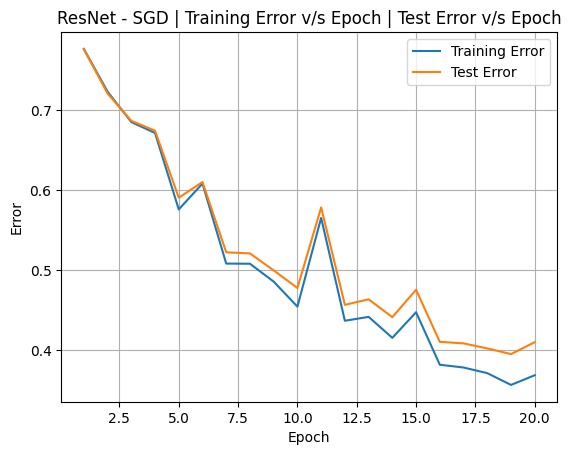

In [11]:
# Table 9 ResNet - SGD
def train_resnet_sgd_step(params, x, y, lr, key, dropout):
    def loss_fn(p):
        return resnet_loss_func(p, x, y, key, dropout=dropout)
    loss, grads = jax.value_and_grad(loss_fn)(params)
    updated_params = {k: params[k]-lr*grads[k] for k in params.keys()}
    return updated_params, loss

def fit_sgd_resnet(train_x, train_y, test_x, test_y, lr, dropout, epochs=20, batch_size=64, seed=0):
    key = jax.random.PRNGKey(seed)
    params = init_resnet_params(key)

    train_errors = []
    test_errors = []
    
    for epoch in range(epochs):
        rng = np.random.default_rng(seed + epoch)
        for xn, yn in mini_batch(train_x, train_y, batch_size, rng):
            xn = jnp.array(xn)
            yn = jnp.array(yn)
            key, subkey = jax.random.split(key)
            params, loss = train_resnet_sgd_step(params, xn, yn, lr, subkey, dropout)

        train_accuracy = float(resnet_accuracy(params, jnp.array(train_x), jnp.array(train_y)))
        train_errors.append(1-train_accuracy)
        test_accuracy = float(resnet_accuracy(params, jnp.array(test_x), jnp.array(test_y)))
        test_errors.append(1-test_accuracy)
        print(f"[ResNet - SGD] epoch={epoch+1:02d} | loss={float(loss):.4f} | test_accuracy={test_accuracy:.4f}")
    return params, train_errors, test_errors

# Table 9 ResNet - SGD
train_x_resnet = train_x.reshape(-1, 1, 32, 32)
test_x_resnet  = test_x.reshape(-1, 1, 32, 32)
params, train_errors, test_errors = fit_sgd_resnet(train_x_resnet, train_y, test_x_resnet, test_y, lr=0.01, dropout=0.5)
plot_errors(train_errors, test_errors, "ResNet - SGD | Training Error v/s Epoch | Test Error v/s Epoch")

In [12]:
os.makedirs("saved_models/resnet_table_9", exist_ok=True)
np.save("saved_models/resnet_table_9/sgd_train.npy", np.array(train_errors))
np.save("saved_models/resnet_table_9/sgd_test.npy",  np.array(test_errors))
np.savez("saved_models/resnet_table_9/sgd_model.npz",
        layer1_conv_W=np.array(params["layer1_conv_W"]), layer1_conv_b=np.array(params["layer1_conv_b"]),
        layer2_conv_W=np.array(params["layer2_conv_W"]), layer2_conv_b=np.array(params["layer2_conv_b"]),
        layer3_projection_W=np.array(params["layer3_projection_W"]), layer3_projection_b=np.array(params["layer3_projection_b"]),
        layer6_conv_W=np.array(params["layer6_conv_W"]), layer6_conv_b=np.array(params["layer6_conv_b"]),
        layer7_conv_W=np.array(params["layer7_conv_W"]), layer7_conv_b=np.array(params["layer7_conv_b"]),
        layer8_projection_W=np.array(params["layer8_projection_W"]), layer8_projection_b=np.array(params["layer8_projection_b"]),
        output_fc_W=np.array(params["output_fc_W"]), output_fc_b=np.array(params["output_fc_b"]),)

[ResNet - SGDM] epoch=01 | loss=2.4802 | test_accuracy=0.2238
[ResNet - SGDM] epoch=02 | loss=2.0651 | test_accuracy=0.2796
[ResNet - SGDM] epoch=03 | loss=1.7888 | test_accuracy=0.3183
[ResNet - SGDM] epoch=04 | loss=2.1600 | test_accuracy=0.3373
[ResNet - SGDM] epoch=05 | loss=1.9089 | test_accuracy=0.4128
[ResNet - SGDM] epoch=06 | loss=1.4662 | test_accuracy=0.4006
[ResNet - SGDM] epoch=07 | loss=1.9279 | test_accuracy=0.4754
[ResNet - SGDM] epoch=08 | loss=1.3829 | test_accuracy=0.4808
[ResNet - SGDM] epoch=09 | loss=1.3487 | test_accuracy=0.5061
[ResNet - SGDM] epoch=10 | loss=1.2059 | test_accuracy=0.5257
[ResNet - SGDM] epoch=11 | loss=1.4911 | test_accuracy=0.4406
[ResNet - SGDM] epoch=12 | loss=1.5418 | test_accuracy=0.5472
[ResNet - SGDM] epoch=13 | loss=1.6735 | test_accuracy=0.5535
[ResNet - SGDM] epoch=14 | loss=1.4367 | test_accuracy=0.5553
[ResNet - SGDM] epoch=15 | loss=1.4293 | test_accuracy=0.5309
[ResNet - SGDM] epoch=16 | loss=0.8176 | test_accuracy=0.5920
[ResNet 

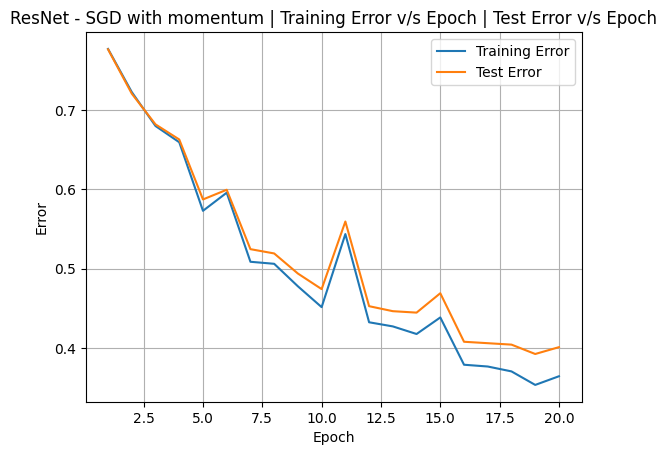

In [13]:
# ResNet Table 9 - SGD with momentum
def train_resnet_sgdm_step(params, mean_g, x, y, lr, beta, key, dropout):
    def loss_fn(p):
        return resnet_loss_func(p, x, y, key, dropout=dropout)
    loss, grads = jax.value_and_grad(loss_fn)(params)
    new_mean_g = {}
    new_params = {}
    for name in params.keys():
        mg = (1.0-beta)*mean_g[name]+grads[name]*beta
        w_new = params[name] - lr * mg
        new_mean_g[name] = mg
        new_params[name] = w_new
    return new_params, new_mean_g, loss

def fit_sgdm_resnet(train_x, train_y, test_x, test_y, lr, dropout, beta=0.9, epochs=20, batch_size=64, seed=0):
    key = jax.random.PRNGKey(seed)
    params = init_resnet_params(key)
    mean_g = {k: jnp.zeros_like(v) for k, v in params.items()}
    train_errors=[]
    test_errors=[]
    for epoch in range(epochs):
        rng = np.random.default_rng(seed + epoch)
        for xn, yn in mini_batch(train_x, train_y, batch_size, rng):
            xn = jnp.array(xn)
            yn = jnp.array(yn)
            key, subkey = jax.random.split(key)
            params, mean_g, loss = train_resnet_sgdm_step(params, mean_g, xn, yn, lr, beta, subkey, dropout)
        
        train_accuracy = float(resnet_accuracy(params, jnp.array(train_x), jnp.array(train_y)))
        train_errors.append(1-train_accuracy)
        test_accuracy = float(resnet_accuracy(params, jnp.array(test_x), jnp.array(test_y)))
        test_errors.append(1-test_accuracy)
        print(f"[ResNet - SGDM] epoch={epoch+1:02d} | loss={float(loss):.4f} | test_accuracy={test_accuracy:.4f}")
    return params, train_errors, test_errors

# ResNet Table 9 - SGDM
train_x_resnet = train_x.reshape(-1, 1, 32, 32)
test_x_resnet  = test_x.reshape(-1, 1, 32, 32)
params, train_errors, test_errors = fit_sgdm_resnet(train_x_resnet, train_y, test_x_resnet, test_y, lr=0.01, dropout=0.5)
plot_errors(train_errors, test_errors, "ResNet - SGD with momentum | Training Error v/s Epoch | Test Error v/s Epoch")

In [14]:
np.save("saved_models/resnet_table_9/sgdm_train.npy", np.array(train_errors))
np.save("saved_models/resnet_table_9/sgdm_test.npy",  np.array(test_errors))
np.savez("saved_models/resnet_table_9/sgdm_model.npz",
        layer1_conv_W=np.array(params["layer1_conv_W"]), layer1_conv_b=np.array(params["layer1_conv_b"]),
        layer2_conv_W=np.array(params["layer2_conv_W"]), layer2_conv_b=np.array(params["layer2_conv_b"]),
        layer3_projection_W=np.array(params["layer3_projection_W"]), layer3_projection_b=np.array(params["layer3_projection_b"]),
        layer6_conv_W=np.array(params["layer6_conv_W"]), layer6_conv_b=np.array(params["layer6_conv_b"]),
        layer7_conv_W=np.array(params["layer7_conv_W"]), layer7_conv_b=np.array(params["layer7_conv_b"]),
        layer8_projection_W=np.array(params["layer8_projection_W"]), layer8_projection_b=np.array(params["layer8_projection_b"]),
        output_fc_W=np.array(params["output_fc_W"]), output_fc_b=np.array(params["output_fc_b"]),)

[ResNet - Adam] epoch=01 | loss=2.1113 | test_accuracy=0.4527
[ResNet - Adam] epoch=02 | loss=1.0332 | test_accuracy=0.5030
[ResNet - Adam] epoch=03 | loss=1.0944 | test_accuracy=0.5546
[ResNet - Adam] epoch=04 | loss=1.7904 | test_accuracy=0.5889
[ResNet - Adam] epoch=05 | loss=1.2069 | test_accuracy=0.6053
[ResNet - Adam] epoch=06 | loss=0.9701 | test_accuracy=0.6233
[ResNet - Adam] epoch=07 | loss=1.5111 | test_accuracy=0.6309
[ResNet - Adam] epoch=08 | loss=1.1435 | test_accuracy=0.6486
[ResNet - Adam] epoch=09 | loss=0.5519 | test_accuracy=0.6603
[ResNet - Adam] epoch=10 | loss=1.0786 | test_accuracy=0.6665
[ResNet - Adam] epoch=11 | loss=0.7225 | test_accuracy=0.6710
[ResNet - Adam] epoch=12 | loss=1.1091 | test_accuracy=0.6880
[ResNet - Adam] epoch=13 | loss=0.9247 | test_accuracy=0.6845
[ResNet - Adam] epoch=14 | loss=1.4370 | test_accuracy=0.6951
[ResNet - Adam] epoch=15 | loss=1.0933 | test_accuracy=0.6942
[ResNet - Adam] epoch=16 | loss=0.7886 | test_accuracy=0.6943
[ResNet 

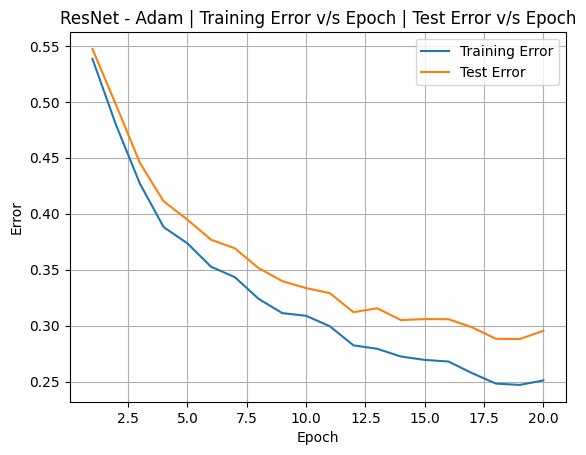

In [15]:
# ResNet Table 9 - Adam
def train_resnet_adam_step(params, mean_g, mean_g2, x, y, lr, beta1, beta2, key, dropout, eps=1e-9):
    def loss_fn(p):
        return resnet_loss_func(p, x, y, key, dropout=dropout)
    loss, grads = jax.value_and_grad(loss_fn)(params)

    new_params = {}
    new_mean_g = {}
    new_mean_g2 = {}

    for name in params.keys():
        g = grads[name]
        mg = beta1*mean_g[name]+(1.0-beta1)*g
        mg2 = beta2*mean_g2[name]+(1.0-beta2)*(g*g)
        w_new = params[name]-lr* mg/(jnp.sqrt(mg2)+eps)

        new_params[name] = w_new
        new_mean_g[name] = mg
        new_mean_g2[name] = mg2

    return new_params, new_mean_g, new_mean_g2, loss

def fit_adam_resnet(train_x, train_y, test_x, test_y, lr, dropout, beta1=0.9, beta2=0.999, epochs=20, batch_size=64, seed=0):
    key = jax.random.PRNGKey(seed)
    params = init_resnet_params(key)
    mean_g = {k: jnp.zeros_like(v) for k, v in params.items()}
    mean_g2 = {k: jnp.zeros_like(v) for k, v in params.items()}

    train_errors=[]
    test_errors=[]

    for epoch in range(epochs):
        rng = np.random.default_rng(seed + epoch)
        for xn, yn in mini_batch(train_x, train_y, batch_size, rng):
            xn = jnp.array(xn)
            yn = jnp.array(yn)
            key, subkey = jax.random.split(key)
            (params, mean_g, mean_g2, loss) = train_resnet_adam_step(params, mean_g, mean_g2, xn, yn, lr=lr, beta1=beta1, beta2=beta2, key=subkey, dropout=dropout)

        train_accuracy = float(resnet_accuracy(params, jnp.array(train_x), jnp.array(train_y)))
        train_errors.append(1-train_accuracy)
        test_accuracy = float(resnet_accuracy(params, jnp.array(test_x), jnp.array(test_y)))
        test_errors.append(1-test_accuracy)
        print(f"[ResNet - Adam] epoch={epoch+1:02d} | loss={float(loss):.4f} | test_accuracy={test_accuracy:.4f}")

    return params, train_errors, test_errors

train_x_resnet = train_x.reshape(-1, 1, 32, 32)
test_x_resnet  = test_x.reshape(-1, 1, 32, 32)
params, train_errors, test_errors = fit_adam_resnet(train_x_resnet, train_y, test_x_resnet, test_y, lr=0.001, dropout=0.5)
plot_errors(train_errors, test_errors, "ResNet - Adam | Training Error v/s Epoch | Test Error v/s Epoch")

In [16]:
np.save("saved_models/resnet_table_9/adam_train.npy", np.array(train_errors))
np.save("saved_models/resnet_table_9/adam_test.npy",  np.array(test_errors))
np.savez("saved_models/resnet_table_9/adam_model.npz",
        layer1_conv_W=np.array(params["layer1_conv_W"]), layer1_conv_b=np.array(params["layer1_conv_b"]),
        layer2_conv_W=np.array(params["layer2_conv_W"]), layer2_conv_b=np.array(params["layer2_conv_b"]),
        layer3_projection_W=np.array(params["layer3_projection_W"]), layer3_projection_b=np.array(params["layer3_projection_b"]),
        layer6_conv_W=np.array(params["layer6_conv_W"]), layer6_conv_b=np.array(params["layer6_conv_b"]),
        layer7_conv_W=np.array(params["layer7_conv_W"]), layer7_conv_b=np.array(params["layer7_conv_b"]),
        layer8_projection_W=np.array(params["layer8_projection_W"]), layer8_projection_b=np.array(params["layer8_projection_b"]),
        output_fc_W=np.array(params["output_fc_W"]), output_fc_b=np.array(params["output_fc_b"]),)